In [2]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))


In [3]:
from netCDF4 import Dataset 
import os
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import seaborn as sns
import numpy as np
import plotly.express as px

import pathlib
import cartopy.feature as cfeature
from matplotlib import pyplot as plt
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize

import plotly.express as px
import plotly.graph_objects as go



In [4]:
import pickle
import torch
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

# Path to the pickle file
pickle_file_path = '/mydata/deepcloud/shared/results-temp/afno_column_1percent_Emb128_clean_tendency_normTarg/test/y_pred_2d.pickle'

# Load the pickle file
with open(pickle_file_path, 'rb') as f:
    y_pred_2d = pickle.load(f)

# Function to inspect the object
def inspect_pickle_object(obj):
    if isinstance(obj, torch.Tensor):
        print(f'Torch Tensor Shape: {obj.shape}')
        print(f'Device: {obj.device}')
        print(f'Data Type: {obj.dtype}')
    elif isinstance(obj, np.ndarray):
        print(f'NumPy Array Shape: {obj.shape}')
        print(f'Data Type: {obj.dtype}')
    elif isinstance(obj, list):
        print(f'List Length: {len(obj)}')
        if len(obj) > 0:
            first_elem = obj[0]
            print(f'First Element Type: {type(first_elem)}')
            if isinstance(first_elem, (torch.Tensor, np.ndarray)):
                print(f'First Element Shape: {first_elem.shape}')
    elif isinstance(obj, dict):
        print(f'Dictionary with Keys: {list(obj.keys())}')
        for key, value in obj.items():
            print(f'\nKey: {key}')
            inspect_pickle_object(value)
    else:
        print('Unhandled type.')

# Inspect the loaded object
inspect_pickle_object(y_pred_2d)


Torch Tensor Shape: torch.Size([81920, 70, 7])
Device: cpu
Data Type: torch.float32


In [6]:
os.getcwd()
file_tendencies = '../../../../../mydata/deepcloud/salman/dataset/tmp/ml_ecrad_ape_R2B05_myrunscript_1year_183min_atm_3d_DOM01_ml_0001_lonlat.nc'

#file_tendencies = '../../../../../s3/deepcloud/deepcloud/icon_tendencies/year1/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_DOM01_ml_0001_lonlat.nc'

# file_tendencies = '../../../../../s3/deepcloud/deepcloud/icon_tendencies/year1/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_inputs_DOM01_ml_0001_lonlat.nc'
#file_tendencies = '../../../../../s3/deepcloud/deepcloud/icon_tendencies/year2/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_inputs_DOM01_ml_0001_lonlat.nc'

# file_tendencies = '../../../../../s3/deepcloud/deepcloud/icon_tendencies/year1/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_restart_atm_DOM01_20010207T120000Z.nc'



# Open the dataset
ds = xr.open_dataset(file_tendencies)

# size
file_size = os.path.getsize(file_tendencies)

# Convert to a human-readable format (e.g., MB)
file_size_gb = file_size / (1024 ** 3)
print(f'File size: {file_size_gb:.2f} GB')

File size: 102.63 GB


In [7]:




# Print global attributes
print("Global Attributes:")
for attr in ds.attrs:
    print(f"{attr}: {ds.attrs[attr]}")


# Print dimensions
print("\nDimensions:")
for dim, size in ds.dims.items():
    print(f"{dim}: size {size}")

# Print variables and selected attributes
print("\nVariables and Selected Descriptions:")
for var in ds.data_vars:
    print(f"\n{var}:")
    print(f"  Shape: {ds[var].shape}")
    print(f"  Dimensions: {ds[var].dims}")
    print(f"  Size: {ds[var].size}")
    # print(f"  Data type: {ds[var].dtype}")
    # print(" Attributes:")
    if 'standard_name' in ds[var].attrs:
        print(f"    Name: {ds[var].attrs['long_name']}")
    if 'units' in ds[var].attrs:
        print(f"    Units: {ds[var].attrs['units']}")
    if 'param' in ds[var].attrs:
        print(f"    Param: {ds[var].attrs['param']}")


# Select a single data point
time_index = 0
height_index = 0
cell_index = 0

single_point = ds.isel(time=time_index, height=height_index, ncells=cell_index)


# Coordinates
print("\nCoordinates:")
for coord_name in single_point.coords:
    coord_data = single_point[coord_name]
    long_name = coord_data.attrs.get("long_name", "-")
    units = coord_data.attrs.get("units", "-")

    print(f"{coord_name}:")
    print(f"  Long Name: {long_name}")
    print(f"  Value: {coord_data.values}")
    print(f"  Units: {units}")


ds.close()



Global Attributes:
CDI: Climate Data Interface version 1.8.4 (http://mpimet.mpg.de/cdi)
Conventions: CF-1.6
number_of_grid_used: 8
grid_file_uri: http://icon-downloads.mpimet.mpg.de/grids/public/icon_grid_0008_R02B05_G.nc
uuidOfHGrid: 0df795de-1dce-11b2-8c3f-4f045d5627af
uuidOfVGrid: 9fa9ccae-3da0-4392-9630-ad15a5401c20
institution: Max Planck Institute for Meteorology/Deutscher Wetterdienst
title: ICON simulation
source: git@github.com:schemms/icon.git@d55fd06fb85d8aec6bff9fc85fd27addb655d22c
history: /scratch/snx3000/gbertoli/icon/bin/icon at 20230511 133909
references: see MPIM/DWD publications
comment: Guillaume Bertoli, ETHZ (gbertoli) on nid07025 (Linux 5.3.18-24.46_6.0.29-cray_ari_c x86_64)

Dimensions:
time: size 237
ncells: size 81920
vertices: size 3
height: size 70
height_2: size 70
bnds: size 2

Variables and Selected Descriptions:

clon_bnds:
  Shape: (81920, 3)
  Dimensions: ('ncells', 'vertices')
  Size: 245760

clat_bnds:
  Shape: (81920, 3)
  Dimensions: ('ncells', 've

/tmp/ipykernel_958/771271149.py:9: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim, size in ds.dims.items():



Coordinates:
time:
  Long Name: -
  Value: 2000-01-01 00:00:00
  Units: -
clon:
  Long Name: center longitude
  Value: 0.6283185482025146
  Units: radian
clat:
  Long Name: center latitude
  Value: 1.561352252960205
  Units: radian
height:
  Long Name: generalized_height
  Value: 1.0
  Units: -
height_2:
  Long Name: generalized_height
  Value: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54.
 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70.]
  Units: -


In [15]:
with Dataset(file_tendencies, mode='r') as ds:
    # Print dimensions
    print("Dimensions:")
    for dim in ds.dimensions:
        print(f"{dim}: {len(ds.dimensions[dim])}")
    
    # Print specific variable shapes
    print("\nWind variable shapes:")
    print(f"u shape: {ds['u'].shape}")
    print(f"v shape: {ds['v'].shape}")
    print(f"w shape: {ds['w'].shape}")

Dimensions:
time: 240
ncells: 81920
vertices: 3
height: 70
bnds: 2
height_2: 71

Wind variable shapes:
u shape: (240, 70, 81920)
v shape: (240, 70, 81920)
w shape: (240, 71, 81920)


In [1]:
import os
from netCDF4 import Dataset

# Base paths
INPUT_BASE = "/s3/deepcloud/deepcloud/icon_tendencies"
OUTPUT_BASE = "/s3/deepcloud/deepcloud/icon_tendencies"

# Loop through years 1 to 12
for year in range(1, 13):
    print(f"Checking year {year}...")

    # Construct input and output file paths
    input_file = os.path.join(INPUT_BASE, f"year{year}", "ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_inputs_DOM01_ml_0001_lonlat.nc")
    output_file = os.path.join(OUTPUT_BASE, f"year{year}", "ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_DOM01_ml_0001_lonlat.nc")

    # Open the input and output files
    with Dataset(input_file, mode='r') as ds_in, Dataset(output_file, mode='r') as ds_out:
        # Get the number of time steps in each file
        num_timesteps_in = len(ds_in.dimensions['time'])
        num_timesteps_out = len(ds_out.dimensions['time'])

        print(f"Input file: {input_file}")
        print(f"Number of time steps: {num_timesteps_in}")

        print(f"Output file: {output_file}")
        print(f"Number of time steps: {num_timesteps_out}")

        # Check if the number of time steps matches the expected value
        if num_timesteps_in != 240 or num_timesteps_out != 240:
            print("Warning: Number of time steps does not match the expected value of 240.")

        print("---")

Checking year 1...
Input file: /s3/deepcloud/deepcloud/icon_tendencies/year1/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_inputs_DOM01_ml_0001_lonlat.nc
Number of time steps: 240
Output file: /s3/deepcloud/deepcloud/icon_tendencies/year1/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_DOM01_ml_0001_lonlat.nc
Number of time steps: 240
---
Checking year 2...
Input file: /s3/deepcloud/deepcloud/icon_tendencies/year2/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_inputs_DOM01_ml_0001_lonlat.nc
Number of time steps: 240
Output file: /s3/deepcloud/deepcloud/icon_tendencies/year2/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_DOM01_ml_0001_lonlat.nc
Number of time steps: 240
---
Checking year 3...
Input file: /s3/deepcloud/deepcloud/icon_tendencies/year3/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_inputs_DOM01_ml_0001_lonlat.nc
Number of time steps: 240
Output file: /s3/deepcloud/deepcloud/icon_tendencies/year3/ml_ecrad_ape_R2B05_myrunscript_1year_1

In [11]:
file_tendencies2 = '../../../../../s3/deepcloud/deepcloud/icon_tendencies/year1/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_DOM01_ml_0001_lonlat.nc'
ds2 = xr.open_dataset(file_tendencies2)


# Print global attributes
print("Global Attributes:")
for attr in ds2.attrs:
    print(f"{attr}: {ds2.attrs[attr]}")


# Print dimensions
print("\nDimensions:")
for dim, size in ds2.dims.items():
    print(f"{dim}: size {size}")

# Print variables and selected attributes
print("\nVariables and Selected Descriptions:")
for var in ds2.data_vars:
    print(f"\n{var}:")
    print(f"  Shape: {ds2[var].shape}")
    print(f"  Dimensions: {ds2[var].dims}")
    print(f"  Size: {ds2[var].size}")
    # print(f"  Data type: {ds[var].dtype}")
    # print(" Attributes:")
    if 'standard_name' in ds2[var].attrs:
        print(f"    Name: {ds2[var].attrs['long_name']}")
    if 'units' in ds2[var].attrs:
        print(f"    Units: {ds2[var].attrs['units']}")
    if 'param' in ds2[var].attrs:
        print(f"    Param: {ds2[var].attrs['param']}")


# Select a single data point
time_index = 0
height_index = 0
cell_index = 0

single_point = ds2.isel(time=time_index, height=height_index, ncells=cell_index)


Global Attributes:
CDI: Climate Data Interface version 2.2.2 (https://mpimet.mpg.de/cdi)
Conventions: CF-1.6
number_of_grid_used: 8
grid_file_uri: http://icon-downloads.mpimet.mpg.de/grids/public/icon_grid_0008_R02B05_G.nc
uuidOfHGrid: 0df795de-1dce-11b2-8c3f-4f045d5627af
uuidOfVGrid: a89672a5-6e04-4a89-9630-ad15a5401ce0
institution: Max Planck Institute for Meteorology/Deutscher Wetterdienst
title: ICON simulation
source: git@github.com:C2SM/icon.git@2f92ef1246a1c46eb606c6fb94c5818bc68b27d7
history: /scratch/snx3000/gbertoli/icon_tendencies/bin/icon at 20240715 163749
references: see MPIM/DWD publications
comment: Guillaume Bertoli, ETHZ (gbertoli) on nid06794 (Linux 5.3.18-24.46_6.0.29-cray_ari_c x86_64)

Dimensions:
time: size 240
ncells: size 81920
vertices: size 3
height: size 70
bnds: size 2

Variables and Selected Descriptions:

clon_bnds:
  Shape: (81920, 3)
  Dimensions: ('ncells', 'vertices')
  Size: 245760

clat_bnds:
  Shape: (81920, 3)
  Dimensions: ('ncells', 'vertices')


/tmp/ipykernel_45425/3076174075.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim, size in ds2.dims.items():


In [6]:
# check some values:
import xarray as xr
import numpy as np

file_tendencies2 = '../../../../../s3/deepcloud/deepcloud/icon_tendencies/year1/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_inputs_DOM01_ml_0001_lonlat.nc'
ds2 = xr.open_dataset(file_tendencies2)

# Select specific data points
time_indices = [0, 50, 100, 150, 200]  # Example time indices
height_indices = [0, 35, 69]  # Example height indices
cell_indices = [0, 20630, 40960, 81919]  # Example cell indices

# Variables to investigate
variables = ['u', 'v', 'w', 'pres', 'geopot',
             'qc', 'qi', 'qv', 'clc']

# Print selected data points for each variable
for var in variables:
    print(f"\nVariable: {var}")
    for t in time_indices:
        if var == 'w':
            height_dim = 'height_2'
            height_indices_to_use = height_indices
        else:
            height_dim = 'height'
            height_indices_to_use = height_indices
            
        for h in height_indices_to_use:
            for c in cell_indices:
                value = ds2[var].isel(time=t, **{height_dim: h}, ncells=c).values
                print(f"  Time: {t}, {height_dim}: {h}, Cell: {c}, Value: {value}")
                



Variable: u
  Time: 0, height: 0, Cell: 0, Value: 0.016145866364240646
  Time: 0, height: 0, Cell: 20630, Value: 12.593877792358398
  Time: 0, height: 0, Cell: 40960, Value: 19.290067672729492
  Time: 0, height: 0, Cell: 81919, Value: 20.306720733642578
  Time: 0, height: 35, Cell: 0, Value: 0.01815379597246647
  Time: 0, height: 35, Cell: 20630, Value: 14.198780059814453
  Time: 0, height: 35, Cell: 40960, Value: 21.744098663330078
  Time: 0, height: 35, Cell: 81919, Value: 22.888912200927734
  Time: 0, height: 69, Cell: 0, Value: 0.005381288472563028
  Time: 0, height: 69, Cell: 20630, Value: 2.989415407180786
  Time: 0, height: 69, Cell: 40960, Value: 4.538420677185059
  Time: 0, height: 69, Cell: 81919, Value: 4.780899524688721
  Time: 50, height: 0, Cell: 0, Value: -3.221642017364502
  Time: 50, height: 0, Cell: 20630, Value: 25.93132972717285
  Time: 50, height: 0, Cell: 40960, Value: 32.39992904663086
  Time: 50, height: 0, Cell: 81919, Value: 22.286745071411133
  Time: 50, hei

  Time: 0, height: 69, Cell: 0, Value: 96443.4140625
  Time: 0, height: 69, Cell: 20630, Value: 102372.734375
  Time: 0, height: 69, Cell: 40960, Value: 102183.765625
  Time: 0, height: 69, Cell: 81919, Value: 102141.4375
  Time: 50, height: 0, Cell: 0, Value: 12.859554290771484
  Time: 50, height: 0, Cell: 20630, Value: 16.30211067199707
  Time: 50, height: 0, Cell: 40960, Value: 16.16371726989746
  Time: 50, height: 0, Cell: 81919, Value: 15.98420238494873
  Time: 50, height: 35, Cell: 0, Value: 18210.412109375
  Time: 50, height: 35, Cell: 20630, Value: 22571.232421875
  Time: 50, height: 35, Cell: 40960, Value: 22279.220703125
  Time: 50, height: 35, Cell: 81919, Value: 22214.619140625
  Time: 50, height: 69, Cell: 0, Value: 97275.5703125
  Time: 50, height: 69, Cell: 20630, Value: 102489.7890625
  Time: 50, height: 69, Cell: 40960, Value: 102244.7578125
  Time: 50, height: 69, Cell: 81919, Value: 102312.1640625
  Time: 100, height: 0, Cell: 0, Value: 11.326441764831543
  Time: 100

In [ ]:
# check some values:
import xarray as xr
import numpy as np

file_tendencies2 = '../../../../../s3/deepcloud/deepcloud/icon_tendencies/year1/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_DOM01_ml_0001_lonlat.nc'
ds2 = xr.open_dataset(file_tendencies2)

# Select specific data points
time_indices = [0, 50, 100, 150, 200]  # Example time indices
height_indices = [0, 35, 69]  # Example height indices
cell_indices = [0, 20630, 40960, 81919]  # Example cell indices

# Variables to investigate
variables = ['ddt_temp_sum', 'temp', 'ddt_temp_dyn', 'ddt_u_sum', 'ddt_v_sum',
             'ddt_qv_conv', 'ddt_qc_conv', 'ddt_qi_conv']

# Print selected data points for each variable
for var in variables:
    print(f"\nVariable: {var}")
    for t in time_indices:
        for h in height_indices:
            for c in cell_indices:
                value = ds2[var].isel(time=t, height=h, ncells=c).values
                print(f"  Time: {t}, Height: {h}, Cell: {c}, Value: {value}")

# Calculate statistics for each variable
for var in variables:
    data = ds2[var].values
    mean = np.mean(data)
    var = np.var(data)
    print(f"\nVariable: {var}")
    print(f"  Mean: {mean}")
    print(f"  Variance: {var}")


Variable: ddt_temp_sum
  Time: 0, Height: 0, Cell: 0, Value: -2.7449319532024674e-05
  Time: 0, Height: 0, Cell: 20630, Value: -2.6170637283939868e-05
  Time: 0, Height: 0, Cell: 40960, Value: -2.6233907192363404e-05
  Time: 0, Height: 0, Cell: 81919, Value: -2.6247980713378638e-05
  Time: 0, Height: 35, Cell: 0, Value: -2.0689736629719846e-05
  Time: 0, Height: 35, Cell: 20630, Value: -2.4612330889794976e-05
  Time: 0, Height: 35, Cell: 40960, Value: -2.4365606805076823e-05
  Time: 0, Height: 35, Cell: 81919, Value: -2.43088070419617e-05
  Time: 0, Height: 69, Cell: 0, Value: -0.0022120848298072815
  Time: 0, Height: 69, Cell: 20630, Value: -0.0010442117927595973
  Time: 0, Height: 69, Cell: 40960, Value: -0.0009406516328454018
  Time: 0, Height: 69, Cell: 81919, Value: -0.0009141307091340423
  Time: 50, Height: 0, Cell: 0, Value: -1.0337948879168835e-05
  Time: 50, Height: 0, Cell: 20630, Value: -6.368403546730406e-07
  Time: 50, Height: 0, Cell: 40960, Value: -6.131630811978539e-07

In [9]:
import h5py
import numpy as np
import glob

def explore_h5_structure(file_path):
    """Explore the structure and contents of an HDF5 file."""
    with h5py.File(file_path, 'r') as f:
        print("=== HDF5 File Structure ===")
        print("\nKeys in file:", list(f.keys()))
        
        print("\n=== Detailed Dataset Information ===")
        for key in f.keys():
            dataset = f[key]
            print(f"\nDataset: {key}")
            print(f"Shape: {dataset.shape}")
            print(f"Dtype: {dataset.dtype}")
            print(f"Compression: {dataset.compression}")
            print(f"Chunks: {dataset.chunks}")
            
            # Print attributes if any
            if len(dataset.attrs) > 0:
                print("Attributes:")
                for attr_name, attr_value in dataset.attrs.items():
                    print(f"  {attr_name}: {attr_value}")
            
            # Print some basic statistics
            data = dataset[:]
            # Print first few values
            print("First few values:", data.flatten()[:5])

def explore_h5_timestamps(h5_dir):
    """Explore timestamps in existing H5 files"""
    print("\n=== H5 Files Time Information ===")
    
    # Get all h5 files in the directory
    pattern = os.path.join(h5_dir, "*.h5")
    h5_files = sorted(glob.glob(pattern))
    
    if not h5_files:
        print(f"No H5 files found in {h5_dir}")
        return
        
    print(f"Found {len(h5_files)} H5 files")
    
    # Look at first few files in detail
    for f in h5_files[:5]:  # Look at first 5 files
        basename = os.path.basename(f)
        print(f"\nFile: {basename}")
        
        # Extract timestamp from filename
        try:
            time_str = basename.split('time_')[-1].replace('.h5', '')
            time_val = float(time_str)
            print(f"Timestamp from filename: {time_val}")
        except:
            print("Could not extract timestamp from filename")
        
        # Look inside the file
        try:
            with h5py.File(f, 'r') as h5f:
                print("File attributes:", list(h5f.attrs.keys()))
                for key in h5f.attrs.keys():
                    print(f"  {key}: {h5f.attrs[key]}")
                print("Datasets:", list(h5f.keys()))
        except Exception as e:
            print(f"Error reading file: {e}")
            
    # Look at last file too
    if len(h5_files) > 5:
        print("\nLast file:")
        f = h5_files[-1]
        basename = os.path.basename(f)
        print(f"File: {basename}")
        try:
            time_str = basename.split('time_')[-1].replace('.h5', '')
            time_val = float(time_str)
            print(f"Timestamp from filename: {time_val}")
        except:
            print("Could not extract timestamp from filename")

# Example usage:
h5_dir = "/s3/deepcloud/deepcloud/h5_data_all_chuncked_2/"
explore_h5_timestamps(h5_dir)



# Use the function
file_path = "/s3/deepcloud/deepcloud/h5_data_all_chuncked_2/ml_ecrad_ape_R2B05_myrunscript_1year_183min_atm_3d_DOM01_ml_0001_lonlat_idx0000_time_8928.400390625.h5"
explore_h5_structure(file_path)



=== H5 Files Time Information ===


NameError: name 'os' is not defined

In [8]:


# Use the function
file_path = "/mydata/deepcloud/yves/h5_tendency_data_all/inputs/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_inputs_DOM01_ml_0001_lonlat_idx0000_time_0.050000000.h5"
explore_h5_structure(file_path)


# Run the exploration
#explore_h5_timestamps(file_path)
# explore_h5_timestamps(path_tendency)

=== HDF5 File Structure ===

Keys in file: ['w', 'x2d', 'x3d']

=== Detailed Dataset Information ===

Dataset: w
Shape: (81920, 71, 1)
Dtype: float32
Compression: None
Chunks: None
First few values: [0.         0.01676007 0.03404615 0.03856399 0.03873665]

Dataset: x2d
Shape: (81920, 3)
Dtype: float32
Compression: None
Chunks: None
First few values: [ 9.6588805e+04 -9.9999997e-10  3.9423825e-03  9.6590031e+04
 -9.9999997e-10]

Dataset: x3d
Shape: (81920, 70, 8)
Dtype: float32
Compression: None
Chunks: None
First few values: [ 1.6145866e-02 -1.9994097e-04  6.1459725e+05  1.5042712e+01
  0.0000000e+00]


In [3]:
import h5py
import numpy as np

def compare_h5_structures(file1_path, file2_path):
    """
    Compare the data structures of two H5 files.
    
    Args:
        file1_path: Path to first H5 file (your generated file)
        file2_path: Path to second H5 file (target file)
    """
    print("=== H5 File Structure Comparison ===\n")
    
    with h5py.File(file1_path, 'r') as f1, h5py.File(file2_path, 'r') as f2:
        # Compare available datasets
        print("Available datasets:")
        print(f"File 1: {list(f1.keys())}")
        print(f"File 2: {list(f2.keys())}\n")
        
        # Compare structures for each dataset
        common_keys = set(f1.keys()) & set(f2.keys())
        
        for key in common_keys:
            print(f"\nComparing dataset: {key}")
            ds1 = f1[key]
            ds2 = f2[key]
            
            print("\nShape comparison:")
            print(f"File 1: {ds1.shape}")
            print(f"File 2: {ds2.shape}")
            
            print("\nDatatype comparison:")
            print(f"File 1: {ds1.dtype}")
            print(f"File 2: {ds2.dtype}")
            
            print("\nCompression settings:")
            print(f"File 1: {ds1.compression}")
            print(f"File 2: {ds2.compression}")
            
            print("\nChunking settings:")
            print(f"File 1: {ds1.chunks}")
            print(f"File 2: {ds2.chunks}")
            
            # Basic statistics
            print("\nValue statistics:")
            print(f"File 1 - Min: {np.min(ds1[:])}, Max: {np.max(ds1[:])}, Mean: {np.mean(ds1[:])}")
            print(f"File 2 - Min: {np.min(ds2[:])}, Max: {np.max(ds2[:])}, Mean: {np.mean(ds2[:])}")
            
            print("\n" + "="*50)

if __name__ == "__main__":
    # Example usage
    file1 = "/mydata/deepcloud/yves/h5_tendency_data_all/outputs/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_DOM01_ml_0001_lonlat_idx0000_time_0.050000000.h5"
    file2 = "/s3/deepcloud/deepcloud/h5_data_all_chuncked_2/ml_ecrad_ape_R2B05_myrunscript_1year_183min_atm_3d_DOM01_ml_0001_lonlat_idx0000_time_8928.400390625.h5"
    
    compare_h5_structures(file1, file2)

=== H5 File Structure Comparison ===

Available datasets:
File 1: ['y']
File 2: ['x2d', 'x3d', 'y']


Comparing dataset: y

Shape comparison:
File 1: (81920, 70, 8)
File 2: (81920, 71, 4)

Datatype comparison:
File 1: float32
File 2: float32

Compression settings:
File 1: None
File 2: None

Chunking settings:
File 1: None
File 2: None

Value statistics:
File 1 - Min: -0.003288721200078726, Max: 307.4974365234375, Mean: 31.884296417236328
File 2 - Min: 0.0, Max: 1375.553955078125, Mean: 198.5120086669922




=== NetCDF File Structure ===

Dimensions:
time: 240
ncells: 81920
vertices: 3
height: 70
bnds: 2
height_2: 71

Variables:

time:
  Shape: (240,)
  Attributes: ['standard_name', 'units', 'calendar', 'axis']
    standard_name: time
    units: hours since 2001-1-7 00:00:00
    calendar: proleptic_gregorian
    axis: T

clon:
  Shape: (81920,)
  Attributes: ['standard_name', 'long_name', 'units', 'bounds']
    standard_name: longitude
    long_name: center longitude
    units: radian
    bounds: clon_bnds

clon_bnds:
  Shape: (81920, 3)
  Attributes: []

clat:
  Shape: (81920,)
  Attributes: ['standard_name', 'long_name', 'units', 'bounds']
    standard_name: latitude
    long_name: center latitude
    units: radian
    bounds: clat_bnds

clat_bnds:
  Shape: (81920, 3)
  Attributes: []

height:
  Shape: (70,)
  Attributes: ['standard_name', 'long_name', 'axis', 'bounds']
    standard_name: height
    long_name: generalized_height
    axis: Z
    bounds: height_bnds

height_bnds:
  Shape:

In [ ]:

def explore_time_info(file_path):
    """Explore time information in a NetCDF file"""
    with Dataset(file_path, mode='r') as ds:
        # Print time variable information
        print("Time variable attributes:", ds['time'].ncattrs())
        print("Time values:", ds['time'][:])
        
        # If there are units or calendar attributes
        if 'units' in ds['time'].ncattrs():
            print("Time units:", ds['time'].units)
        if 'calendar' in ds['time'].ncattrs():
            print("Calendar:", ds['time'].calendar)
        
        # Print number of time steps
        print("Number of time steps:", len(ds['time'][:]))
        
        # Print first few and last few time values
        print("\nFirst 5 time values:", ds['time'][:5])
        print("Last 5 time values:", ds['time'][-5:])
        
        # If there are time bounds
        if 'time_bnds' in ds.variables:
            print("\nTime bounds:", ds['time_bnds'][:])

def explore_nc_timestamps(nc_file):
    """Explore timestamps in NetCDF file"""
    print("\n=== NetCDF File Time Information ===")
    with Dataset(nc_file, mode='r') as ds:
        time_var = ds['time']
        times = time_var[:]
        
        print("Time variable attributes:", time_var.ncattrs())
        if 'units' in time_var.ncattrs():
            print("Time units:", time_var.units)
        if 'calendar' in time_var.ncattrs():
            print("Calendar:", time_var.calendar)
            
        print("\nNumber of time steps:", len(times))
        print("Time step intervals:", np.diff(times)[:5], "...")
        print("\nFirst 5 time values:", times[:5])
        print("Last 5 time values:", times[-5:])
        
        # Convert to datetime if possible
        if hasattr(time_var, 'units'):
            dates = num2date(times, units=time_var.units, calendar=time_var.calendar)
            print("\nFirst 5 dates:", dates[:5])
            print("Last 5 dates:", dates[-5:])

nc_file = '../../../../../s3/deepcloud/deepcloud/icon_tendencies/year3/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_inputs_DOM01_ml_0001_lonlat.nc'

# Use the function
#explore_time_info(file_tendencies)
explore_nc_timestamps(nc_file)


=== NetCDF File Time Information ===
Time variable attributes: ['standard_name', 'units', 'calendar', 'axis']
Time units: hours since 2001-1-7 00:00:00
Calendar: proleptic_gregorian

Number of time steps: 240
Time step intervals: [3.05 3.05 3.05 3.05 3.05] ...

First 5 time values: [ 0.05  3.1   6.15  9.2  12.25]
Last 5 time values: [740.8  743.85 746.9  749.95 753.  ]

First 5 dates: [cftime.DatetimeProlepticGregorian(2001, 1, 7, 0, 3, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2001, 1, 7, 3, 6, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2001, 1, 7, 6, 9, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2001, 1, 7, 9, 12, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2001, 1, 7, 12, 15, 0, 0, has_year_zero=True)]
Last 5 dates: [cftime.DatetimeProlepticGregorian(2001, 2, 6, 20, 48, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2001, 2, 6, 23, 51, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2

In [14]:
import h5py
import pickle
import numpy as np

def analyze_h5_structure(h5_path):
    """Analyze the basic structure and features of an H5 file."""
    print("\n=== H5 File Structure Analysis ===")
    print(f"File: {h5_path}")
    
    with h5py.File(h5_path, 'r') as f:
        # Basic file info
        print("\nFile Structure:")
        print(f"Number of datasets: {len(f.keys())}")
        print("\nDatasets:")
        
        for key in f.keys():
            dataset = f[key]
            print(f"\n{key}:")
            print(f"  Shape: {dataset.shape}")
            print(f"  Dtype: {dataset.dtype}")
            
            # Print attributes if any
            if len(dataset.attrs) > 0:
                print("  Attributes:")
                for attr_name, attr_value in dataset.attrs.items():
                    print(f"    {attr_name}: {attr_value}")
            
            # If it's a 3D array, show feature dimension
            if len(dataset.shape) == 3:
                print(f"  Number of features: {dataset.shape[-1]}")

def analyze_stats_structure(stats_path):
    """Analyze the structure of the statistics file."""
    print("\n=== Statistics File Structure ===")
    print(f"File: {stats_path}")
    
    with open(stats_path, 'rb') as f:
        stats = pickle.load(f)
    
    print("\nStructure:")
    if isinstance(stats, dict):
        for key in stats.keys():
            print(f"\nKey: {key}")
            if isinstance(stats[key], dict):
                print("  Subkeys:", list(stats[key].keys()))
            else:
                print(f"  Type: {type(stats[key])}")
                if isinstance(stats[key], np.ndarray):
                    print(f"  Shape: {stats[key].shape}")

def main():
    # Paths to your files
    h5_path = "/mydata/deepcloud/salman/dataset/h5_data_all_chuncked/ml_ecrad_ape_R2B05_myrunscript_1year_183min_atm_3d_DOM01_ml_0001_lonlat_idx0000_time_8928.400390625.h5"
    stats_path_old = "/mydata/deepcloud/salman/dataset/h5_data_all_chuncked/normalizer_stats_per_feat.pickle"
    
    stats_path_new = "/mydata/deepcloud/yves/h5_tendency_data_all/normalizer_stats_per_feat.pickle"

    h5_path_new_inputs = "/mydata/deepcloud/yves/h5_tendency_data_all/inputs/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_inputs_DOM01_ml_0001_lonlat_idx0000_time_0.050000000.h5"
    h5_path_new_outputs = "/mydata/deepcloud/yves/h5_tendency_data_all/outputs/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_DOM01_ml_0001_lonlat_idx0000_time_0.050000000.h5"

    # Analyze files
    analyze_h5_structure(h5_path)
    analyze_h5_structure(h5_path_new_inputs)
    analyze_h5_structure(h5_path_new_outputs)
    analyze_stats_structure(stats_path_old)
    analyze_stats_structure(stats_path_new)




if __name__ == "__main__":
    main()


=== H5 File Structure Analysis ===
File: /mydata/deepcloud/salman/dataset/h5_data_all_chuncked/ml_ecrad_ape_R2B05_myrunscript_1year_183min_atm_3d_DOM01_ml_0001_lonlat_idx0000_time_8928.400390625.h5

File Structure:
Number of datasets: 3

Datasets:

x2d:
  Shape: (81920, 6)
  Dtype: float32

x3d:
  Shape: (81920, 70, 6)
  Dtype: float32
  Number of features: 6

y:
  Shape: (81920, 71, 4)
  Dtype: float32
  Number of features: 4

=== H5 File Structure Analysis ===
File: /mydata/deepcloud/yves/h5_tendency_data_all/inputs/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_inputs_DOM01_ml_0001_lonlat_idx0000_time_0.050000000.h5

File Structure:
Number of datasets: 3

Datasets:

w:
  Shape: (81920, 71, 1)
  Dtype: float32
  Number of features: 1

x2d:
  Shape: (81920, 3)
  Dtype: float32

x3d:
  Shape: (81920, 70, 8)
  Dtype: float32
  Number of features: 8

=== H5 File Structure Analysis ===
File: /mydata/deepcloud/yves/h5_tendency_data_all/outputs/ml_ecrad_ape_R2B05_myrunscript_1year_

In [4]:
import pickle
import numpy as np

def analyze_normalizer_stats(stats_path, label=""):
    """Analyze and display the normalization statistics"""
    print(f"\n{'-'*80}")
    print(f"=== Normalizer Statistics Analysis: {label} ===")
    print(f"{'-'*80}")
    
    with open(stats_path, 'rb') as f:
        stats = pickle.load(f)
    
    # Print statistics for each array
    for key in stats.keys():
        print(f"\n{key}:")
        array = stats[key]
        print(f"  Shape: {array.shape}")
        print(f"  dtype: {array.dtype}")
        print(f"  Values: {array}")
       
def compare_stats(yves_path, salman_path):
    """Compare the statistics between the two files"""
    print("\n=== Comparison of Statistics ===")
    
    with open(yves_path, 'rb') as f:
        yves_stats = pickle.load(f)
    with open(salman_path, 'rb') as f:
        salman_stats = pickle.load(f)
    
    # Compare common keys
    common_keys = set(yves_stats.keys()) & set(salman_stats.keys())
    print(f"\nCommon keys: {common_keys}")
    
    print("\nShape comparison:")
    for key in common_keys:
        print(f"\n{key}:")
        print(f"  Yves shape: {yves_stats[key].shape}")
        print(f"  Salman shape: {salman_stats[key].shape}")
    
    # Keys unique to each file
    yves_unique = set(yves_stats.keys()) - set(salman_stats.keys())
    salman_unique = set(salman_stats.keys()) - set(yves_stats.keys())
    
    if yves_unique:
        print(f"\nKeys unique to Yves: {yves_unique}")
    if salman_unique:
        print(f"\nKeys unique to Salman: {salman_unique}")

# Paths to your files
yves_stats = "/mydata/deepcloud/yves/h5_tendency_data_all/normalizer_stats_per_feat.pickle"
yves_stats_updated ='/mydata/deepcloud/yves/h5_tendency_data_all/normalizer_stats_per_feat_updated.pickle'
yves_stats_y2 = "/mydata/deepcloud/yves/h5_tendency_data_all/normalizer_stats_per_feat_y2.pickle"
salman_stats = "/mydata/deepcloud/salman/dataset/h5_data_all_chuncked/normalizer_stats_per_feat.pickle"
update1 = "/mydata/deepcloud/shared/h5_tendency_all/normalizer_stats_per_feat_updated1.pickle"

# Analyze individual files
#analyze_normalizer_stats(yves_stats, "Yves' Stats Most Recent")
#analyze_normalizer_stats(yves_stats_updated, "Yves' Updated")
#analyze_normalizer_stats(yves_stats_y2, "Yves' Y2 Stats")
#analyze_normalizer_stats(salman_stats, "Salman's Stats")
analyze_normalizer_stats(update1, "Update1's Stats")



# Analyze individual files

# Compare the two files
# compare_stats(yves_stats, yves_stats_updated)


--------------------------------------------------------------------------------
=== Normalizer Statistics Analysis: Update1's Stats ===
--------------------------------------------------------------------------------

mean2d:
  Shape: (3,)
  dtype: float64
  Values: [1.01176324e+05 2.49876111e-01 1.22697570e-02]

var2d:
  Shape: (3,)
  dtype: float64
  Values: [1.53300187e+06 1.04230060e-01 4.75828855e-05]

mean3d:
  Shape: (10,)
  dtype: float64
  Values: [4.74103699e+00 4.78387363e-02 1.72210180e+05 3.49226316e+04
 5.18656383e+00 1.16268524e-06 4.83129332e-07 1.69508204e-03
 2.34896404e+02 2.56743463e-05]

var3d:
  Shape: (10,)
  dtype: float64
  Values: [2.44311064e+02 6.99690535e+01 2.78958396e+10 1.31884459e+09
 2.86821789e+02 2.95492843e-10 1.69876408e-11 1.17214320e-05
 1.31038390e+03 1.09368477e-03]


In [2]:
import pickle

stats_file = '/mydata/deepcloud/yves/h5_tendency_data_all/normalizer_stats_per_feat_updated.pickle'

check = '/mydata/deepcloud/shared/results-temp/afno_column_1percent_Emb128_clean_tendency_normTarg/test/train_target_mean.pickle'

with open(check, 'rb') as f:
    check = pickle.load(f)

print(check)



tensor([[-1.3182e-06,  0.0000e+00,  4.0628e-06,  3.4050e-09,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 2.2366e-06,  0.0000e+00,  1.2263e-05, -3.4958e-07,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 4.9427e-07,  0.0000e+00,  4.8769e-06, -1.6483e-07,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-1.5292e-07,  0.0000e+00,  3.0533e-06,  1.4021e-07,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-5.4430e-07,  0.0000e+00,  2.0486e-06,  1.4871e-07,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-9.8814e-07,  0.0000e+00,  1.0984e-06,  1.0921e-07,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-1.5359e-06,  0.0000e+00,  4.3484e-07, -1.1956e-08,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-2.1251e-06,  0.0000e+00,  5.9098e-08, -5.1085e-09,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-2.6873e-06,  0.0000e+00, -1.4760e-07,  1.4300e-08,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-

In [6]:
import pickle

# Specify the path to the pickle file
stats_file = '/mydata/deepcloud/yves/h5_tendency_data_all/normalizer_stats_per_feat_y2.pickle'

# Specify the number of decimal places to display
decimal_places = 20

# Load the statistics from the pickle file
with open(stats_file, 'rb') as f:
    stats = pickle.load(f)

print(f"Statistics loaded from: {stats_file}\n")

print("Output Variables:")
for i, (mean, var) in enumerate(zip(stats['mean'], stats['var'])):
    print(f"Feature {i}:")
    print(f"  Mean: {mean:.{decimal_places}f}")
    print(f"  Variance: {var:.{decimal_places}f}")
    print()

Statistics loaded from: /mydata/deepcloud/yves/h5_tendency_data_all/normalizer_stats_per_feat_y2.pickle

Output Variables:
Feature 0:
  Mean: -0.00000048894632291408
  Variance: 0.00000000761061182153

Feature 1:
  Mean: 234.89640385309883185982
  Variance: 1310.38389500078574201325

Feature 2:
  Mean: -0.00000122859449796169
  Variance: 0.00000000545587198138

Feature 3:
  Mean: 0.00000111562916161693
  Variance: 0.00000000887171756075

Feature 4:
  Mean: -0.00000000051677925850
  Variance: 0.00000000597184165454

Feature 5:
  Mean: -0.00000000565305621473
  Variance: 0.00000000000000137008

Feature 6:
  Mean: 0.00000000102732262246
  Variance: 0.00000000000000019463

Feature 7:
  Mean: 0.00000000006920283759
  Variance: 0.00000000000000000395



### Update target y statistics file

In [14]:
import os
import pickle
import numpy as np

# Load the existing pickle file
input_file = '/mydata/deepcloud/shared/results-temp/h5_tendency_all/normalizer_stats_per_feat_y2.pickle'
with open(input_file, 'rb') as f:
    data = pickle.load(f)

# Print the original data
print("Original data:")
print("Mean:")
for value in data['mean']:
    print(f"{value:.6e}")
print("Variance:")
for value in data['var']:
    print(f"{value:.6e}")
print()

# Remove the 'temp' feature
temp_index = 1  # Index of 'temp' feature
data['mean'] = np.delete(data['mean'], temp_index)
data['var'] = np.delete(data['var'], temp_index)

# Print the updated data
print("Updated data:")
print("Mean:")
for value in data['mean']:
    print(f"{value:.6e}")
print("Variance:")
for value in data['var']:
    print(f"{value:.6e}")
print()

# Save the updated data to a new pickle file
output_file = '/mydata/deepcloud/shared/results-temp/h5_tendency_all/normalizer_stats_per_feat_y2_no_temp.pickle'
with open(output_file, 'wb') as f:
    pickle.dump(data, f)

print(f"Updated data saved to: {output_file}")

Original data:
Mean:
-4.889463e-07
2.348964e+02
-1.228594e-06
1.115629e-06
-5.167793e-10
-5.653056e-09
1.027323e-09
6.920284e-11
Variance:
7.610612e-09
1.310384e+03
5.455872e-09
8.871718e-09
5.971842e-09
1.370082e-15
1.946323e-16
3.945408e-18

Updated data:
Mean:
-4.889463e-07
-1.228594e-06
1.115629e-06
-5.167793e-10
-5.653056e-09
1.027323e-09
6.920284e-11
Variance:
7.610612e-09
5.455872e-09
8.871718e-09
5.971842e-09
1.370082e-15
1.946323e-16
3.945408e-18

Updated data saved to: /mydata/deepcloud/shared/results-temp/h5_tendency_all/normalizer_stats_per_feat_y2_no_temp.pickle


### update stats file by concat w to 3D

In [1]:
import pickle

# Path to the stats file
stats_file = '/mydata/deepcloud/yves/h5_tendency_data_all/normalizer_stats_per_feat_statistics1.pickle'

# Load the stats file
with open(stats_file, 'rb') as f:
    stats = pickle.load(f)

# Print the content of the stats file
print("Content of the stats file:")
for key, value in stats.items():
    print(f"{key}: {value}")


Content of the stats file:
mean_w: [2.56743463e-05]
var_w: [0.00109368]
mean2d: [1.01176324e+05 2.49876111e-01 1.22697570e-02]
var2d: [1.53300187e+06 1.04230060e-01 4.75828855e-05]
mean3d: [4.74103699e+00 4.78387363e-02 1.72210180e+05 3.49226316e+04
 5.18656383e+00 1.16268524e-06 4.83129332e-07 1.69508204e-03]
var3d: [2.44311064e+02 6.99690535e+01 2.78958396e+10 1.31884459e+09
 2.86821789e+02 2.95492843e-10 1.69876408e-11 1.17214320e-05]


In [6]:
import pickle
import numpy as np

stats_file = '/mydata/deepcloud/yves/h5_tendency_data_all/normalizer_stats_per_feat_statistics1.pickle'
new_stats_file = '/mydata/deepcloud/shared/h5_tendency_all/normalizer_stats_per_feat_updated1.pickle'

with open(stats_file, 'rb') as f:
    stats = pickle.load(f)

print("Original stats:")
for key, value in stats.items():
    print(f"{key}: {value}")

# Create a copy of the stats dictionary to modify
new_stats = stats.copy()

mean_w = new_stats['mean_w']
var_w = new_stats['var_w']
mean3d = new_stats['mean3d']
var3d = new_stats['var3d']

mean3d_updated = np.concatenate((mean3d, mean_w))
var3d_updated = np.concatenate((var3d, var_w))

new_stats['mean3d'] = mean3d_updated
new_stats['var3d'] = var3d_updated

# Remove the 'mean_w' and 'var_w' keys from the new stats dictionary
del new_stats['mean_w']
del new_stats['var_w']

print("\nUpdated stats:")
for key, value in new_stats.items():
    print(f"{key}: {value}")

# Save the updated stats dictionary to a new file
with open(new_stats_file, 'wb') as f:
    pickle.dump(new_stats, f)

Original stats:
mean_w: [2.56743463e-05]
var_w: [0.00109368]
mean2d: [1.01176324e+05 2.49876111e-01 1.22697570e-02]
var2d: [1.53300187e+06 1.04230060e-01 4.75828855e-05]
mean3d: [4.74103699e+00 4.78387363e-02 1.72210180e+05 3.49226316e+04
 5.18656383e+00 1.16268524e-06 4.83129332e-07 1.69508204e-03]
var3d: [2.44311064e+02 6.99690535e+01 2.78958396e+10 1.31884459e+09
 2.86821789e+02 2.95492843e-10 1.69876408e-11 1.17214320e-05]

Updated stats:
mean2d: [1.01176324e+05 2.49876111e-01 1.22697570e-02]
var2d: [1.53300187e+06 1.04230060e-01 4.75828855e-05]
mean3d: [4.74103699e+00 4.78387363e-02 1.72210180e+05 3.49226316e+04
 5.18656383e+00 1.16268524e-06 4.83129332e-07 1.69508204e-03
 2.56743463e-05]
var3d: [2.44311064e+02 6.99690535e+01 2.78958396e+10 1.31884459e+09
 2.86821789e+02 2.95492843e-10 1.69876408e-11 1.17214320e-05
 1.09368477e-03]


### update stats file by removing geopotential

In [2]:
import pickle
import numpy as np

def update_stats(stats_path, output_path):
    """Update the stats dictionary by removing geopotential from key3d"""
    with open(stats_path, 'rb') as f:
        stats = pickle.load(f)
    
    # Remove geopotential from key3d
    stats['mean3d'] = np.delete(stats['mean3d'], 3)
    stats['var3d'] = np.delete(stats['var3d'], 3)
    
    # Save the updated stats to a new file
    with open(output_path, 'wb') as f:
        pickle.dump(stats, f)
    
    print(f"Updated stats saved to: {output_path}")

# Path to your original stats file
yves_stats = "/mydata/deepcloud/yves/h5_tendency_data_all/normalizer_stats_per_feat_updated.pickle"

# Path to save the updated stats file
updated_stats = "/mydata/deepcloud/yves/h5_tendency_data_all/normalizer_stats_per_feat_updated.pickle"

# Update the stats and save to a new file
update_stats(yves_stats, updated_stats)

Updated stats saved to: /mydata/deepcloud/yves/h5_tendency_data_all/normalizer_stats_per_feat_updated.pickle


### update stats file adding temperature 

In [7]:
import pickle
import numpy as np

def update_stats(stats_path, temp_stats_path, output_path):
    """Update the stats dictionary by adding temp as the second last entry and save to a new file"""
    with open(stats_path, 'rb') as f:
        stats = pickle.load(f)
    
    with open(temp_stats_path, 'rb') as f:
        temp_stats = pickle.load(f)
    
    print("Original stats:")
    print("mean3d:", stats['mean3d'])
    print("var3d:", stats['var3d'])
    
    # Add temp as the second last entry
    temp_mean = temp_stats['mean'][1]  # Get the second entry from temp_stats['mean']
    temp_var = temp_stats['var'][1]    # Get the second entry from temp_stats['var']
    
    stats['mean3d'] = np.insert(stats['mean3d'], -1, temp_mean)
    stats['var3d'] = np.insert(stats['var3d'], -1, temp_var)
    
    print("\nUpdated stats:")
    print("mean3d:", stats['mean3d'])
    print("var3d:", stats['var3d'])
    
    # Save the updated stats to the output file
    with open(output_path, 'wb') as f:
        pickle.dump(stats, f)
    
    print(f"\nUpdated stats saved to: {output_path}")

# Path to your original stats file
original_stats = "/mydata/deepcloud/shared/h5_tendency_all/normalizer_stats_per_feat_updated1.pickle"

# Path to the stats file containing temp
temp_stats = "/mydata/deepcloud/yves/h5_tendency_data_all/normalizer_stats_per_feat_y2.pickle"

# Path to save the updated stats
updated_stats = "/mydata/deepcloud/shared/h5_tendency_all/normalizer_stats_per_feat_updated1.pickle"

# Update the stats and save to the new file
update_stats(original_stats, temp_stats, updated_stats)

Original stats:
mean3d: [4.74103699e+00 4.78387363e-02 1.72210180e+05 3.49226316e+04
 5.18656383e+00 1.16268524e-06 4.83129332e-07 1.69508204e-03
 2.56743463e-05]
var3d: [2.44311064e+02 6.99690535e+01 2.78958396e+10 1.31884459e+09
 2.86821789e+02 2.95492843e-10 1.69876408e-11 1.17214320e-05
 1.09368477e-03]

Updated stats:
mean3d: [4.74103699e+00 4.78387363e-02 1.72210180e+05 3.49226316e+04
 5.18656383e+00 1.16268524e-06 4.83129332e-07 1.69508204e-03
 2.34896404e+02 2.56743463e-05]
var3d: [2.44311064e+02 6.99690535e+01 2.78958396e+10 1.31884459e+09
 2.86821789e+02 2.95492843e-10 1.69876408e-11 1.17214320e-05
 1.31038390e+03 1.09368477e-03]

Updated stats saved to: /mydata/deepcloud/shared/h5_tendency_all/normalizer_stats_per_feat_updated1.pickle


In [7]:
import pickle
import numpy as np
import pandas as pd
from tabulate import tabulate

def load_stats(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def compare_stats_files():
    # Paths to statistics files
    yves_path = "/mydata/deepcloud/yves/h5_tendency_data_all/normalizer_stats_per_feat.pickle"
    salman_path = "/mydata/deepcloud/salman/dataset/h5_data_all_chuncked/normalizer_stats_per_feat.pickle"
    
    # Load both statistics files
    yves_stats = load_stats(yves_path)
    salman_stats = load_stats(salman_path)
    
    print("\n=== YVES'S FEATURES AND STATISTICS ===")
    print("Target Variable:")
    print(f"w (Vertical velocity) [m/s]:")
    print(f"  Mean: {yves_stats['mean_w'][0]:.6e}")
    print(f"  Variance: {yves_stats['var_w'][0]:.6e}")
    
    # Yves's features
    yves_2d = [
        ('pres_sfc', 'Surface pressure [Pa]'),
        ('cosmu0', 'Cosine of solar zenith angle [-]'),
        ('qv_s', 'Surface water vapor specific humidity [kg/kg]')
    ]
    
    yves_3d = [
        ('u', 'Zonal wind [m/s]'),
        ('v', 'Meridional wind [m/s]'),
        ('geopot', 'Geopotential [m²/s²]'),
        ('pres', 'Pressure [Pa]'),
        ('clc', 'Cloud cover fraction [-]')
        ('qc', 'Cloud water content [kg/kg]'),
        ('qi', 'Cloud ice content [kg/kg]'),
        ('qv', 'Water vapor specific humidity [kg/kg]'),
    ]
    
    # Salman's features
    salman_2d = [
        'pres_sfc_ecrad_in', 'cosmu0_ecrad_in', 'qv_s_ecrad_in',
        'albvisdir_ecrad_in', 'albnirdir_ecrad_in', 'tsfctrad_ecrad_in'
    ]
    
    salman_3d = [
        'clc_ecrad_in', 'temp_ecrad_in', 'pres_ecrad_in',
        'qc_ecrad_in', 'qi_ecrad_in', 'qv_ecrad_in'
    ]
    
    # Create comparison tables
    print("\n=== 2D FEATURES COMPARISON ===")
    print("\nYves's 2D Features:")
    for i, (feat_name, feat_desc) in enumerate(yves_2d):
        print(f"\n{feat_name} - {feat_desc}:")
        print(f"  Mean: {yves_stats['mean2d'][i]:.6e}")
        print(f"  Variance: {yves_stats['var2d'][i]:.6e}")
    
    print("\nSalman's 2D Features:")
    for i, feat_name in enumerate(salman_2d):
        print(f"\n{feat_name}:")
        print(f"  Mean: {salman_stats['mean2d'][i]:.6e}")
        print(f"  Variance: {salman_stats['var2d'][i]:.6e}")
    
    print("\n=== 3D FEATURES COMPARISON ===")
    print("\nYves's 3D Features:")
    for i, (feat_name, feat_desc) in enumerate(yves_3d):
        print(f"\n{feat_name} - {feat_desc}:")
        print(f"  Mean: {yves_stats['mean3d'][i]:.6e}")
        print(f"  Variance: {yves_stats['var3d'][i]:.6e}")
    
    print("\nSalman's 3D Features:")
    for i, feat_name in enumerate(salman_3d):
        print(f"\n{feat_name}:")
        print(f"  Mean: {salman_stats['mean3d'][i]:.6e}")
        print(f"  Variance: {salman_stats['var3d'][i]:.6e}")
    
    # Print array shapes summary
    print("\n=== ARRAY SHAPES SUMMARY ===")
    print("\nYves's arrays:")
    for key, value in yves_stats.items():
        print(f"{key}: shape {value.shape}, dtype {value.dtype}")
    
    print("\nSalman's arrays:")
    for key, value in salman_stats.items():
        print(f"{key}: shape {value.shape}, dtype {value.dtype}")

if __name__ == "__main__":
    compare_stats_files()

<>:37: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
<>:37: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
/tmp/ipykernel_161662/2685924474.py:37: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  ('clc', 'Cloud cover fraction [-]')
/tmp/ipykernel_161662/2685924474.py:37: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  ('clc', 'Cloud cover fraction [-]')
/tmp/ipykernel_161662/2685924474.py:37: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  ('clc', 'Cloud cover fraction [-]')



=== YVES'S FEATURES AND STATISTICS ===
Target Variable:
w (Vertical velocity) [m/s]:
  Mean: 2.567435e-05
  Variance: 1.093685e-03


TypeError: 'tuple' object is not callable


### Looking at the average accross height levels

--> The data quality looks poor. Is this due to the warm up time of the simulation? 

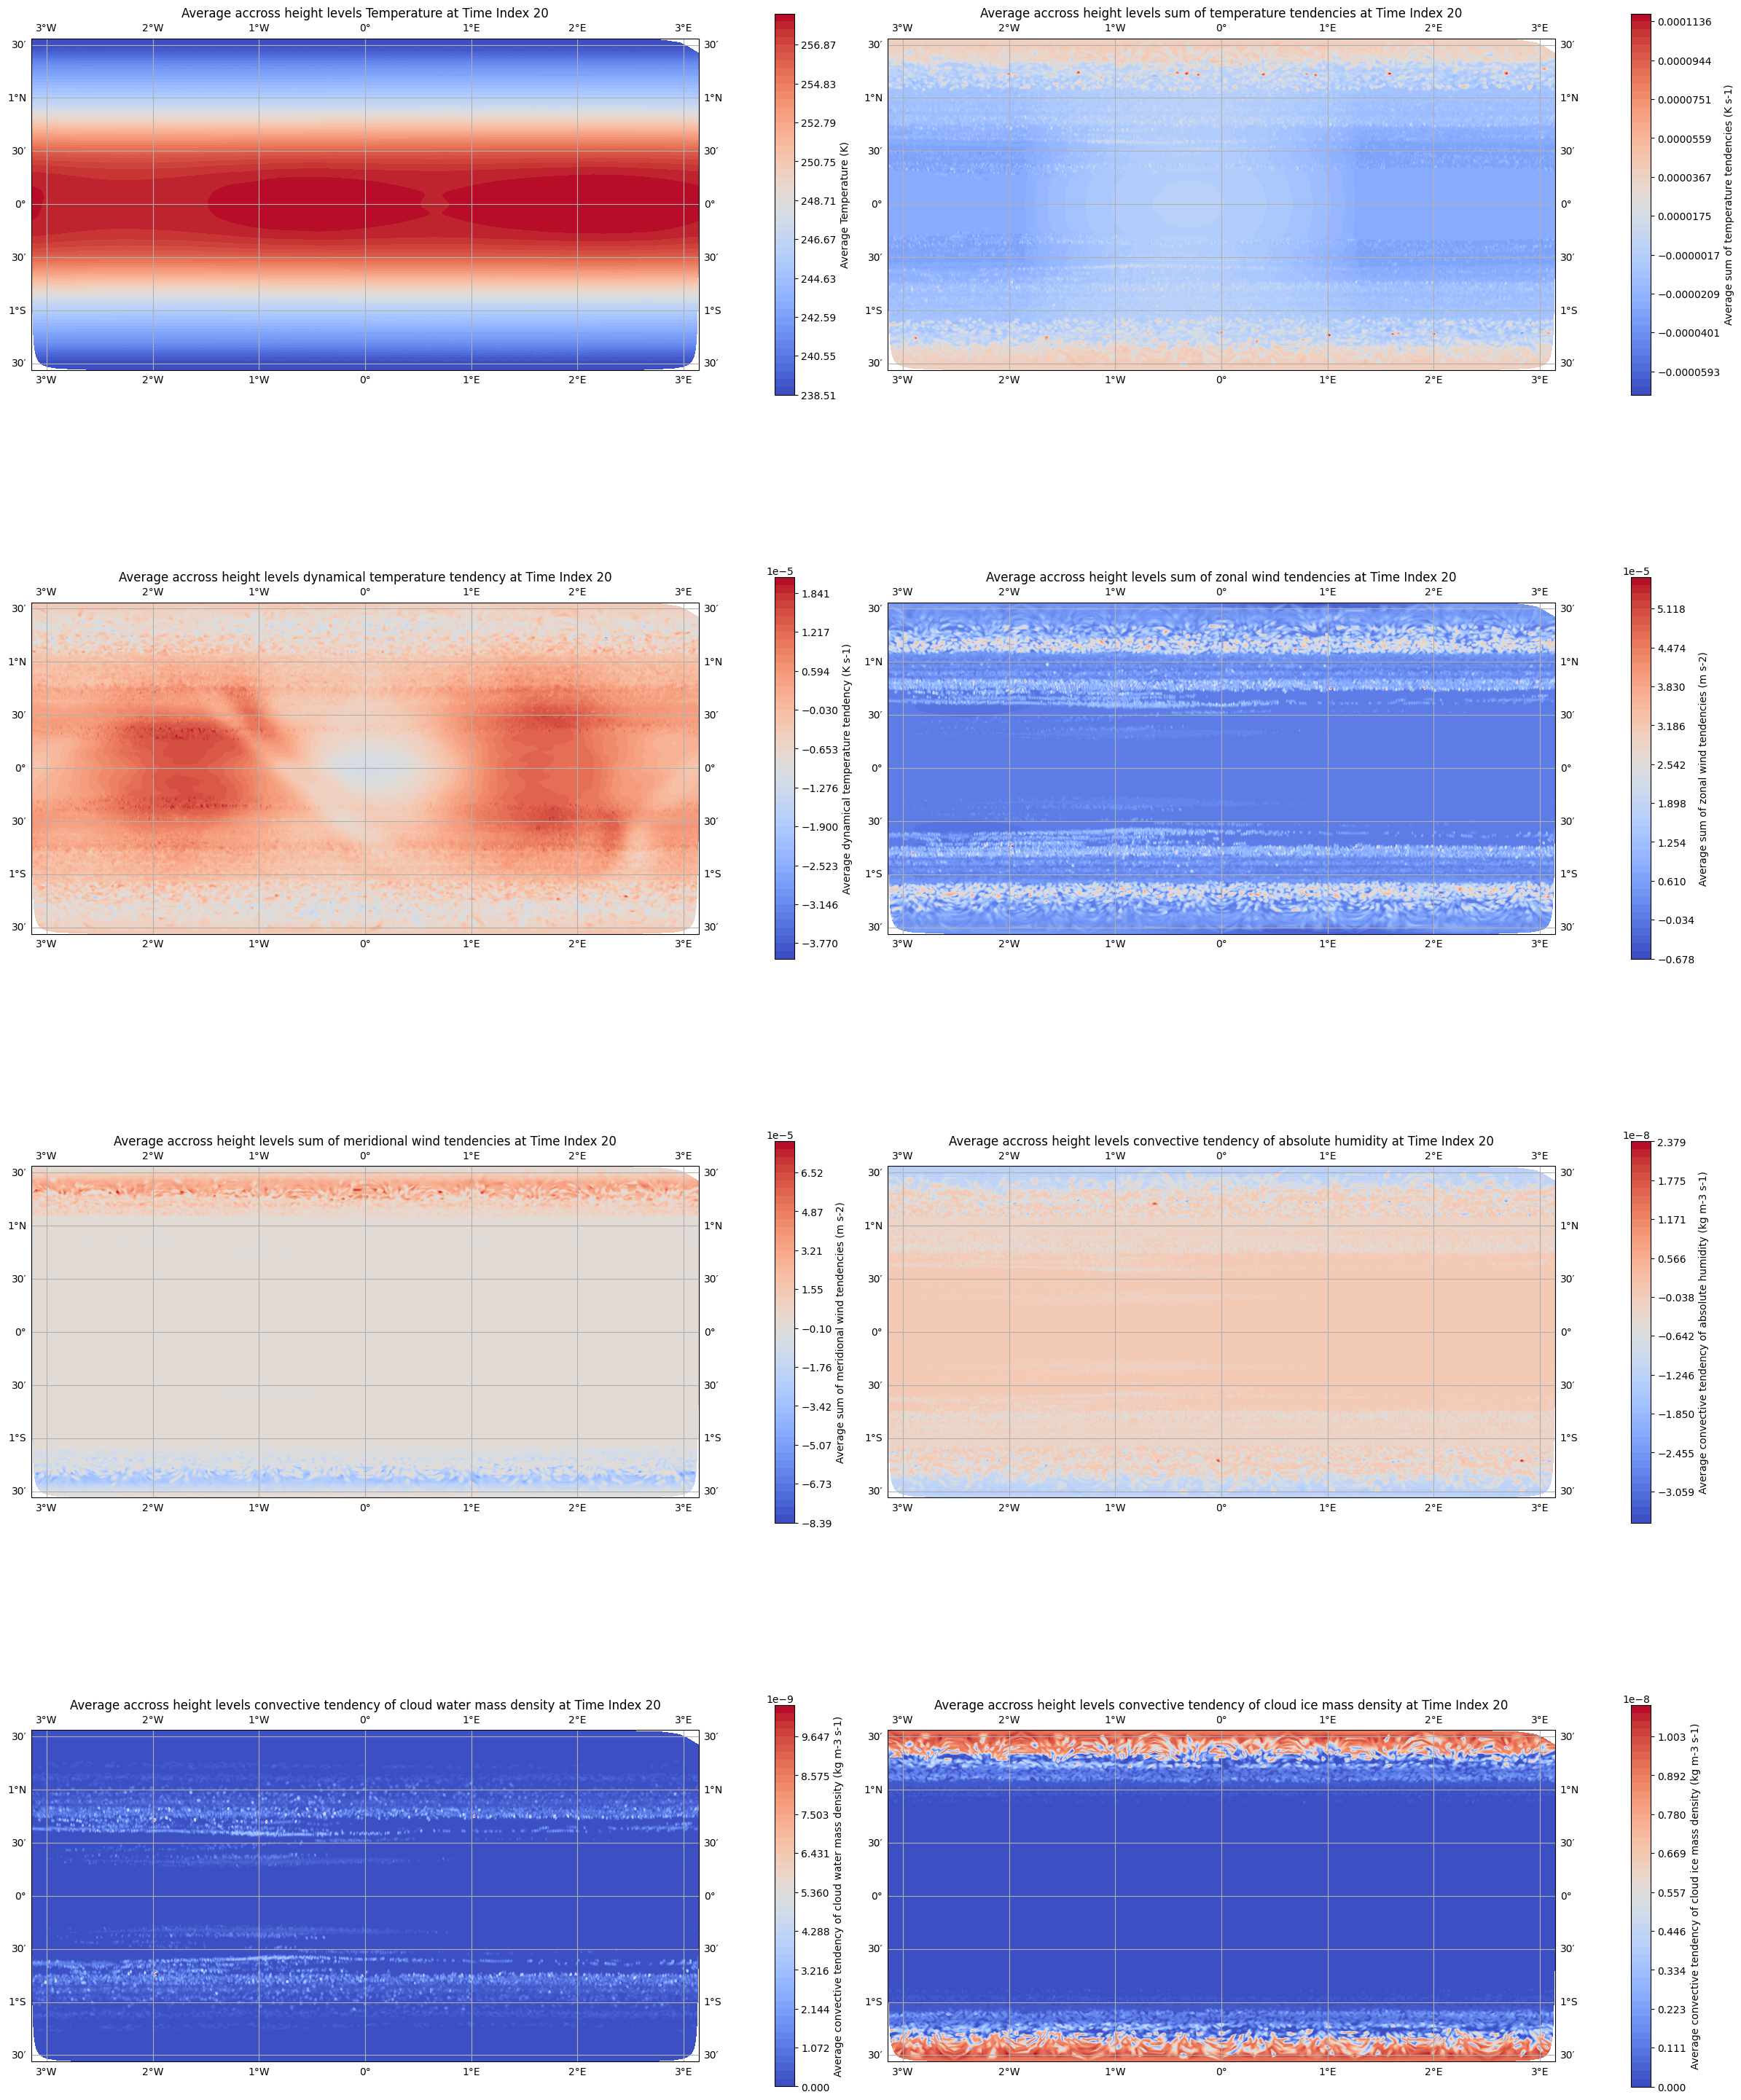

In [13]:
time_index = 20  # Adjust this index to select a different time point
num_levels = 50  # Adjust the number of contour levels

variables = ['temp', 'ddt_temp_sum', 'ddt_temp_dyn', 'ddt_u_sum', 'ddt_v_sum', 'ddt_qv_conv', 'ddt_qc_conv', 'ddt_qi_conv']
num_plots = len(variables)
num_cols = 2
num_rows = (num_plots + 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(24, 8 * num_rows), subplot_kw={'projection': ccrs.PlateCarree()})

for i in range(num_plots):
    var = variables[i]
    row = i // num_cols
    col = i % num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]

    avg_data = ds[var].isel(time=time_index).mean(dim='height')
    avg_data_np = np.asarray(avg_data)

    levels = np.linspace(avg_data_np.min(), avg_data_np.max(), num=num_levels)
    contourf = ax.tricontourf(ds['clon'], ds['clat'], avg_data_np, levels=levels, transform=ccrs.PlateCarree(), cmap='coolwarm')
    cbar = fig.colorbar(contourf, ax=ax, orientation='vertical', fraction=0.025, pad=0.1)
    cbar.set_label(f"Average {ds[var].attrs.get('long_name', var)} ({ds[var].attrs.get('units', '')})")
    ax.set_title(f"Average accross height levels {ds[var].attrs.get('long_name', var)} at Time Index {time_index}")

    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Remove any unused subplots
for i in range(num_plots, num_rows * num_cols):
    row = i // num_cols
    col = i % num_cols
    fig.delaxes(axes[row, col] if num_rows > 1 else axes[col])

plt.tight_layout()
plt.show()
plt.close()
### Average accross height levels at an advanced time step for the tendency data

### Average accross height levels at an advanced time step for the tendency data

--> I have very small values to predict. Can I capture this with a DL model? 

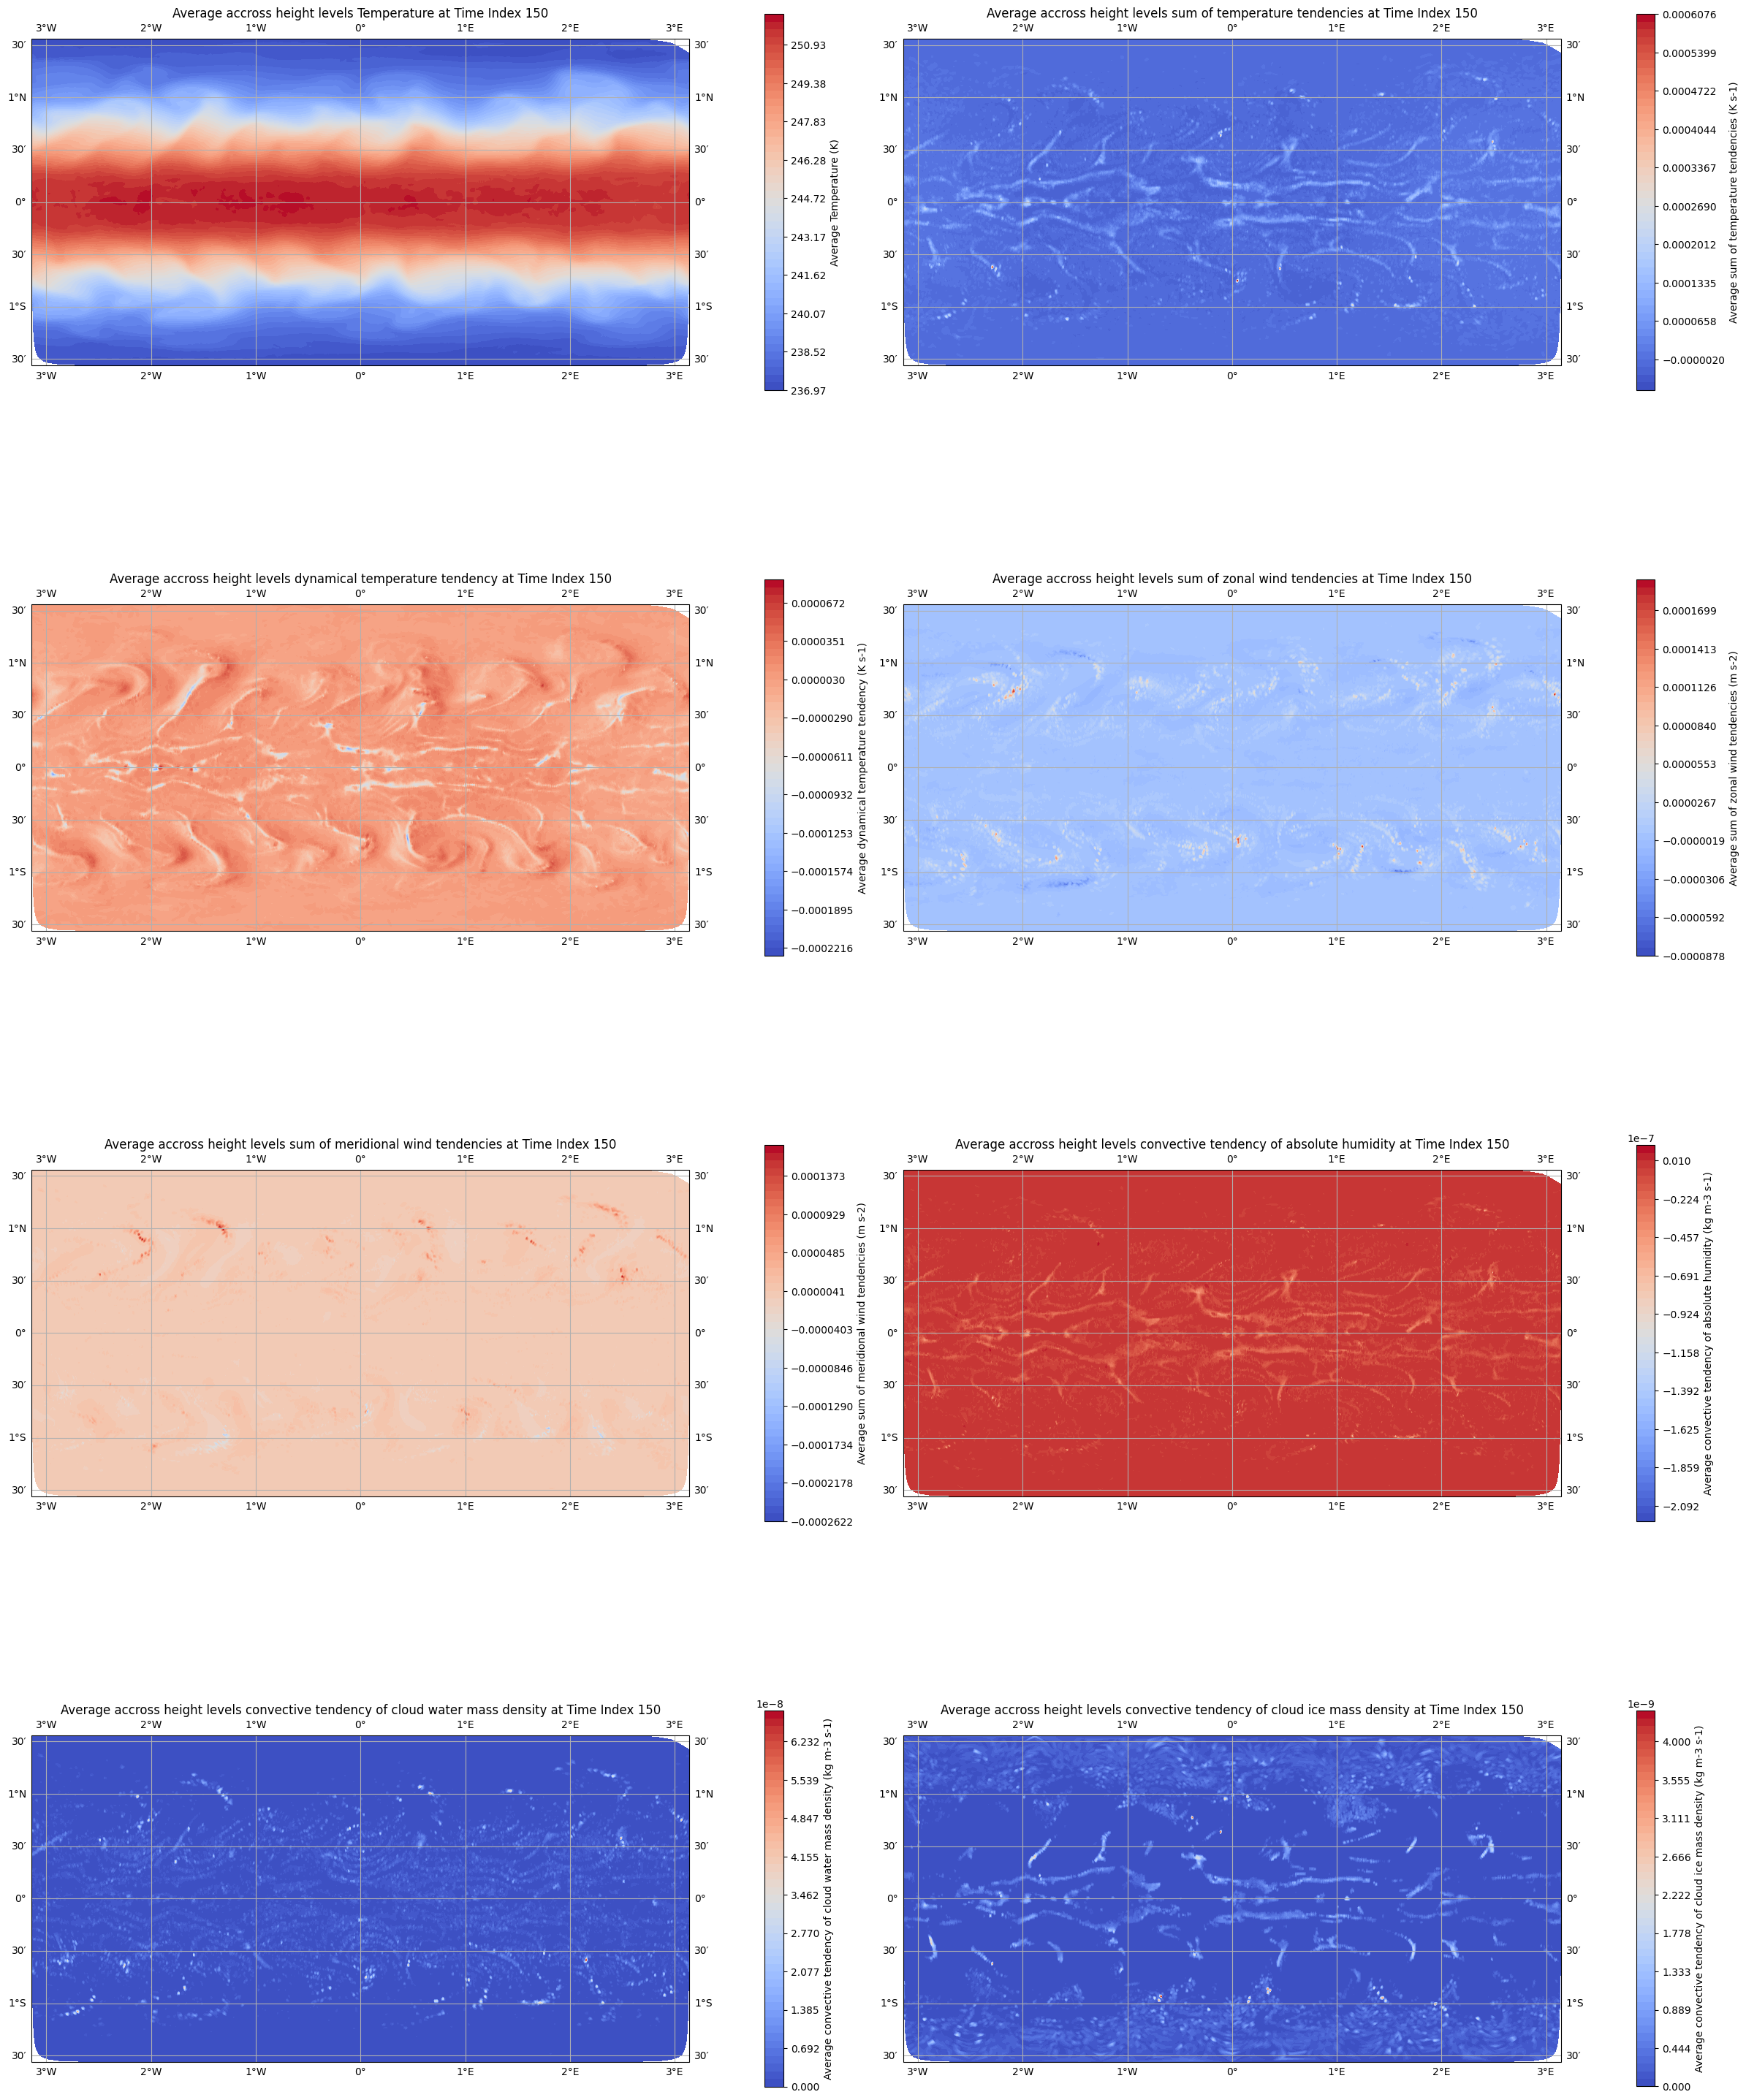

In [14]:
time_index = 150  # Adjust this index to select a different time point
num_levels = 50  # Adjust the number of contour levels

variables = ['temp', 'ddt_temp_sum', 'ddt_temp_dyn', 'ddt_u_sum', 'ddt_v_sum', 'ddt_qv_conv', 'ddt_qc_conv', 'ddt_qi_conv']
num_plots = len(variables)
num_cols = 2
num_rows = (num_plots + 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(24, 8 * num_rows), subplot_kw={'projection': ccrs.PlateCarree()})

for i in range(num_plots):
    var = variables[i]
    row = i // num_cols
    col = i % num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]

    avg_data = ds[var].isel(time=time_index).mean(dim='height')
    avg_data_np = np.asarray(avg_data)

    levels = np.linspace(avg_data_np.min(), avg_data_np.max(), num=num_levels)
    contourf = ax.tricontourf(ds['clon'], ds['clat'], avg_data_np, levels=levels, transform=ccrs.PlateCarree(), cmap='coolwarm')
    cbar = fig.colorbar(contourf, ax=ax, orientation='vertical', fraction=0.025, pad=0.1)
    cbar.set_label(f"Average {ds[var].attrs.get('long_name', var)} ({ds[var].attrs.get('units', '')})")
    ax.set_title(f"Average accross height levels {ds[var].attrs.get('long_name', var)} at Time Index {time_index}")

    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Remove any unused subplots
for i in range(num_plots, num_rows * num_cols):
    row = i // num_cols
    col = i % num_cols
    fig.delaxes(axes[row, col] if num_rows > 1 else axes[col])

plt.tight_layout()
plt.show()
plt.close()

### Interesting behaviout at lower level


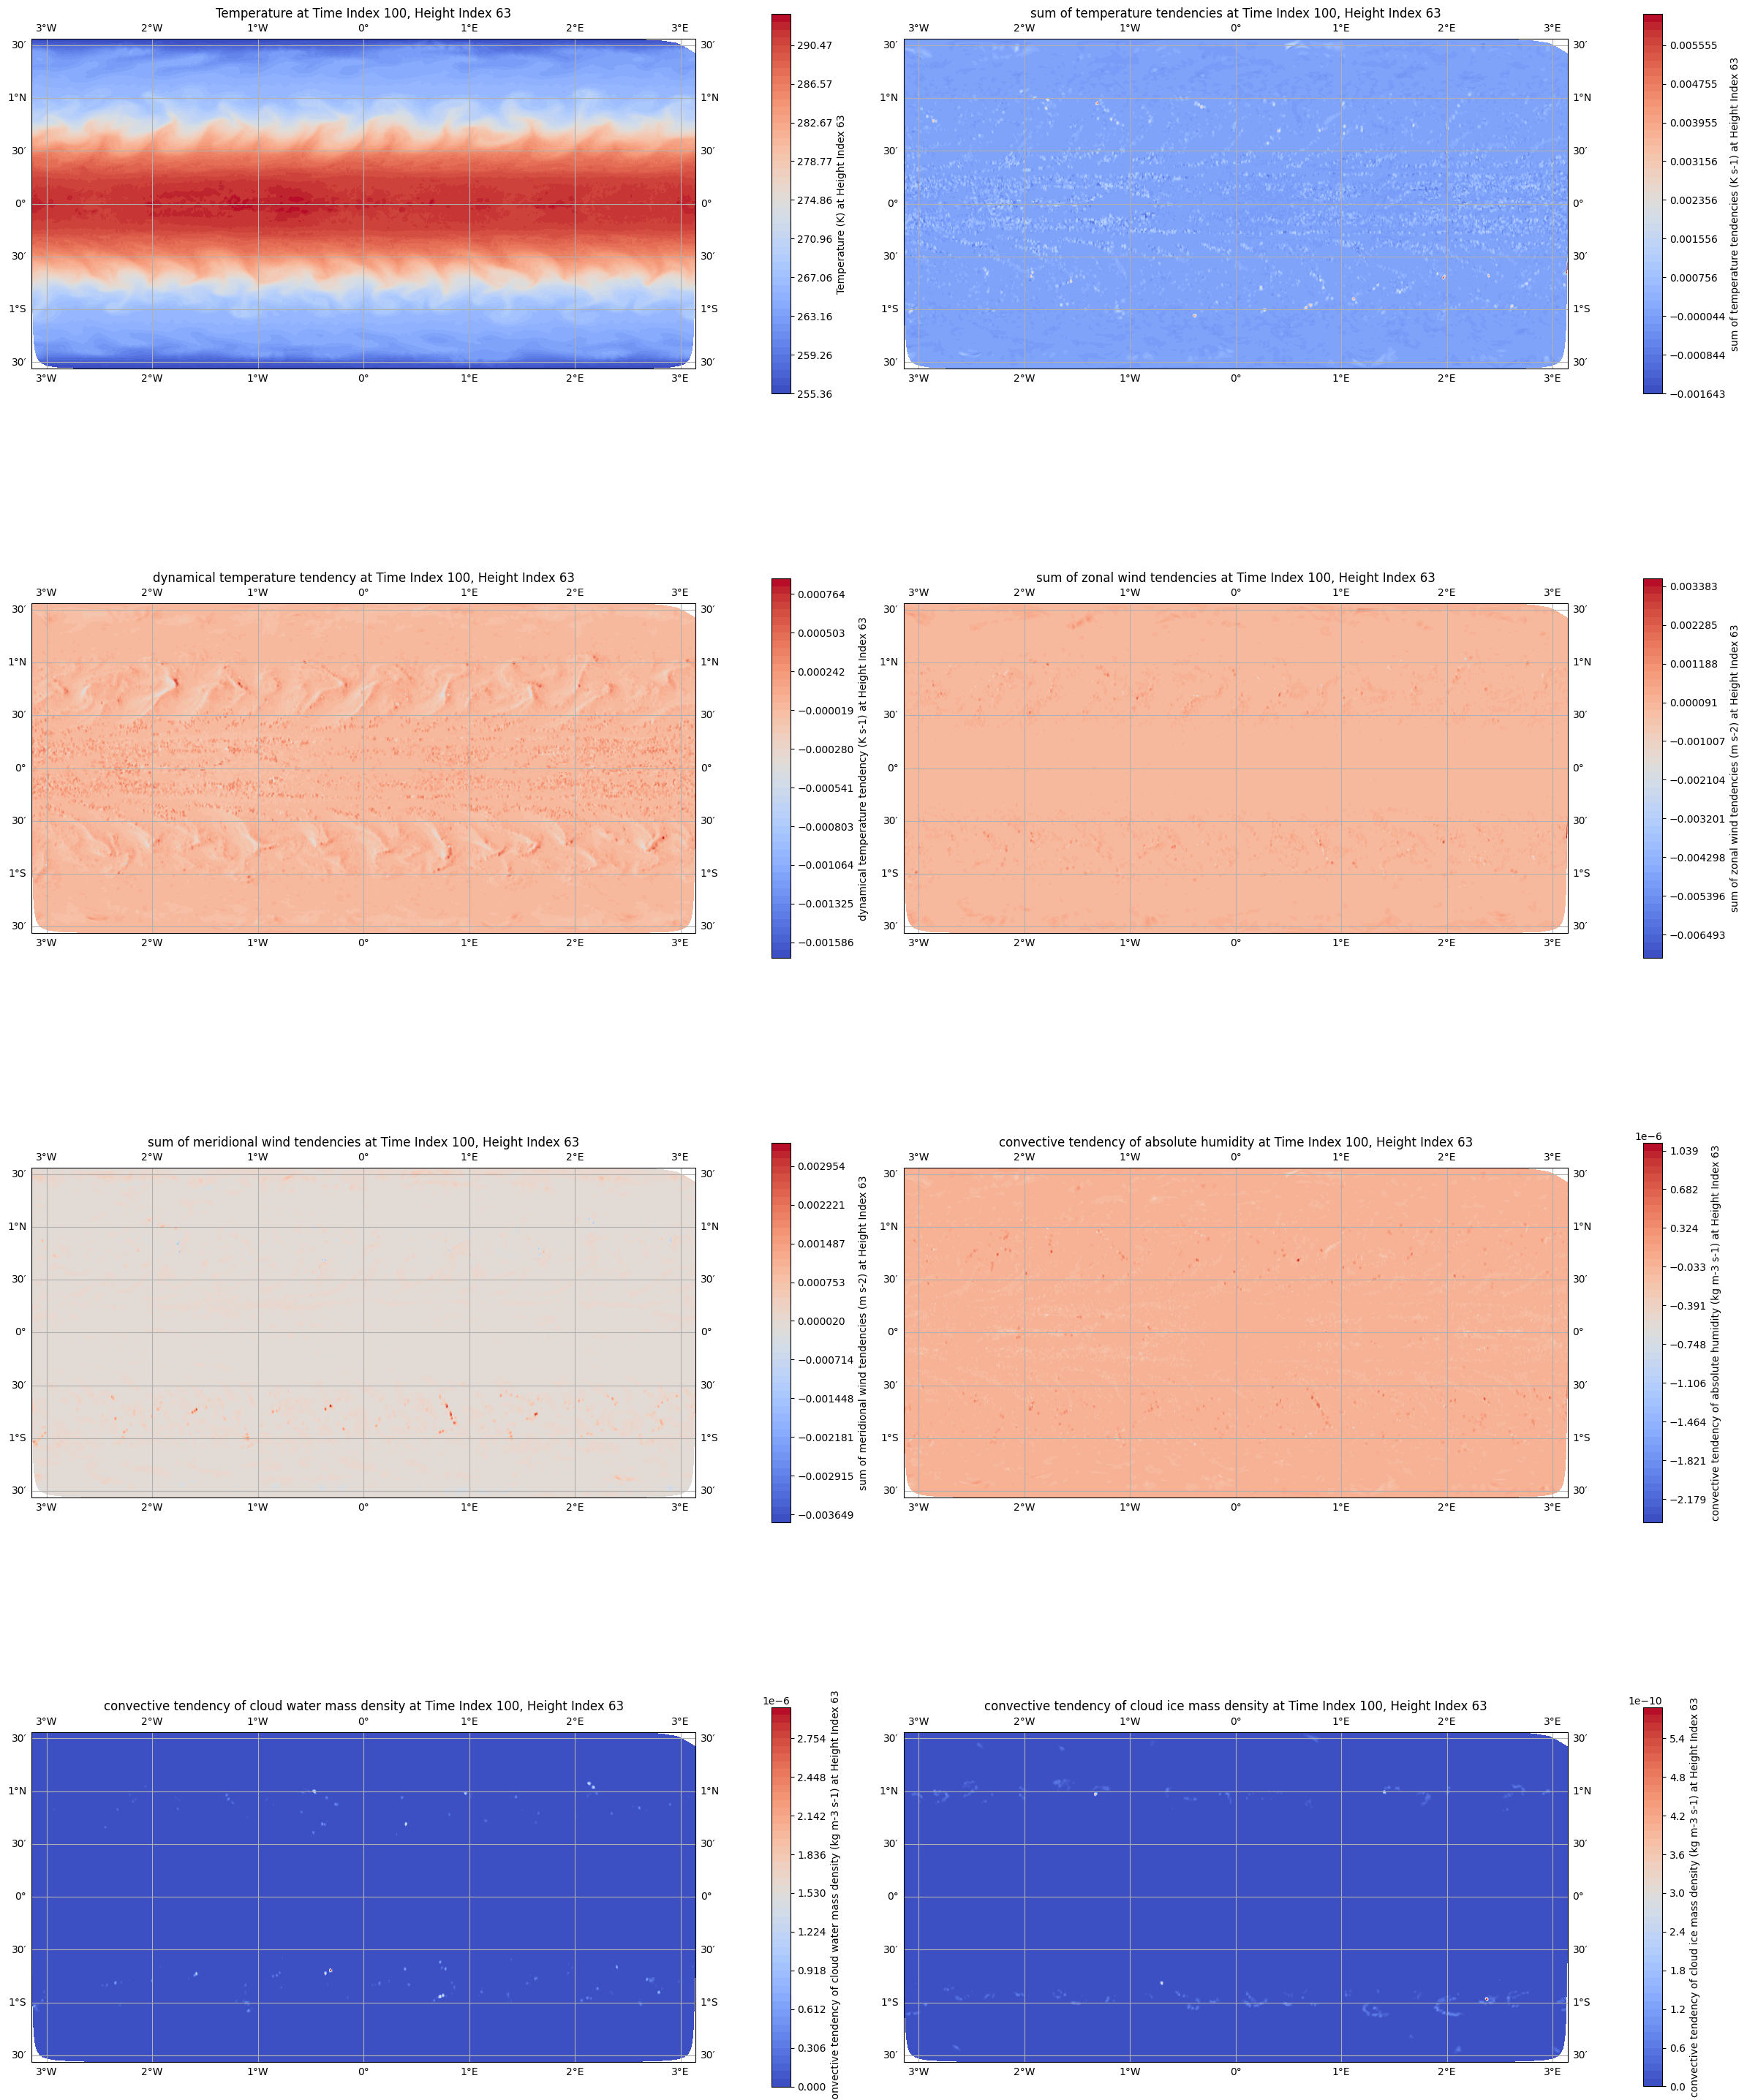

ddt_qc_conv at height index 30: [0. 0. 0. ... 0. 0. 0.]
ddt_qi_conv at height index 30: [0. 0. 0. ... 0. 0. 0.]
ddt_qc_conv at height index 68: [0. 0. 0. ... 0. 0. 0.]
ddt_qi_conv at height index 68: [0. 0. 0. ... 0. 0. 0.]
Non-zero height indices for ddt_qc_conv: [39 39 39 ... 67 67 67]
Non-zero height indices for ddt_qi_conv: [32 32 32 ... 66 66 66]


In [19]:
time_index = 100  # Adjust this index to select a different time point
height_index =63  # Adjust this index to select a specific height level
num_levels = 50  # Adjust the number of contour levels

variables = ['temp', 'ddt_temp_sum', 'ddt_temp_dyn', 'ddt_u_sum', 'ddt_v_sum', 'ddt_qv_conv', 'ddt_qc_conv', 'ddt_qi_conv']
num_plots = len(variables)
num_cols = 2
num_rows = (num_plots + 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(24, 8 * num_rows), subplot_kw={'projection': ccrs.PlateCarree()})

for i in range(num_plots):
    var = variables[i]
    row = i // num_cols
    col = i % num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]

    # Select data at the specified height index
    data = ds[var].isel(time=time_index, height=height_index)
    data_np = np.asarray(data)

    levels = np.linspace(data_np.min(), data_np.max(), num=num_levels)
    contourf = ax.tricontourf(ds['clon'], ds['clat'], data_np, levels=levels, transform=ccrs.PlateCarree(), cmap='coolwarm')
    cbar = fig.colorbar(contourf, ax=ax, orientation='vertical', fraction=0.025, pad=0.1)
    cbar.set_label(f"{ds[var].attrs.get('long_name', var)} ({ds[var].attrs.get('units', '')}) at Height Index {height_index}")
    ax.set_title(f"{ds[var].attrs.get('long_name', var)} at Time Index {time_index}, Height Index {height_index}")

    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Remove any unused subplots
for i in range(num_plots, num_rows * num_cols):
    row = i // num_cols
    col = i % num_cols
    fig.delaxes(axes[row, col] if num_rows > 1 else axes[col])

plt.tight_layout()
plt.show()
plt.close()
### There are quite some zeros in it
height_index = 10
time_index = 150

print(f"ddt_qc_conv at height index 30: {ds['ddt_qc_conv'].isel(time=time_index, height=height_index).values}")
print(f"ddt_qi_conv at height index 30: {ds['ddt_qi_conv'].isel(time=time_index, height=height_index).values}")

height_index=68
print(f"ddt_qc_conv at height index 68: {ds['ddt_qc_conv'].isel(time=time_index, height=height_index).values}")
print(f"ddt_qi_conv at height index 68: {ds['ddt_qi_conv'].isel(time=time_index, height=height_index).values}")

non_zero_heights_qc = np.nonzero(ds['ddt_qc_conv'].isel(time=time_index).values)[0]
non_zero_heights_qi = np.nonzero(ds['ddt_qi_conv'].isel(time=time_index).values)[0]
print(f"Non-zero height indices for ddt_qc_conv: {non_zero_heights_qc}")
print(f"Non-zero height indices for ddt_qi_conv: {non_zero_heights_qi}")

### Plotting the target data as an average over all cells for a certain time index
- See that there are quite some zeros in the data
- I am wondering how to prediction of zonal and meridional wind makes sense 

Number of cells: 81920


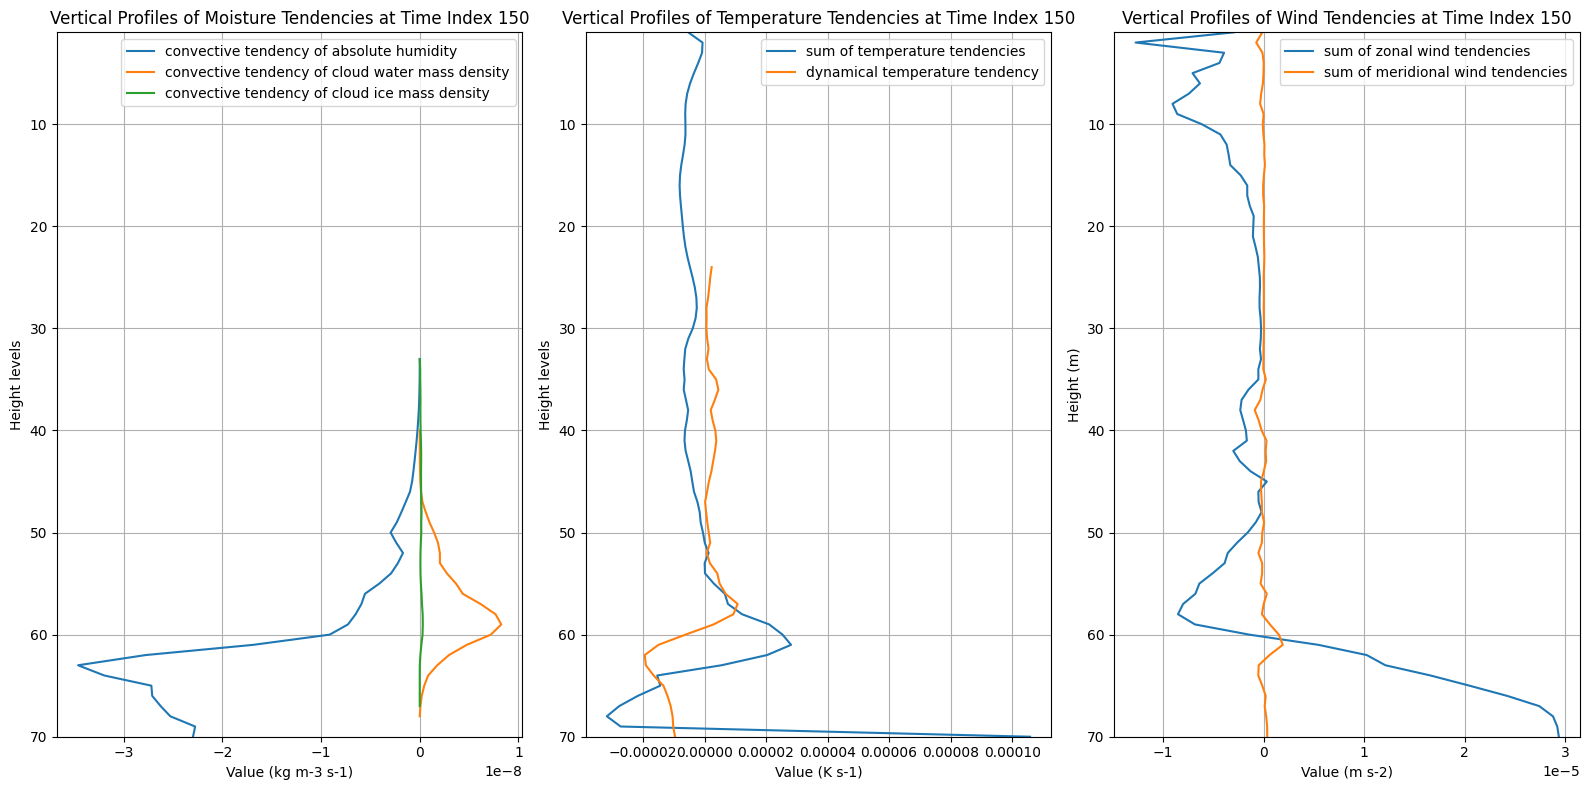

In [24]:

import os
import matplotlib.pyplot as plt
import xarray as xr

file_tendencies = '../../../../../s3/deepcloud/deepcloud/icon_tendencies/year1/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_DOM01_ml_0001_lonlat.nc'
ds = xr.open_dataset(file_tendencies)

# plot over all cells
num_cells = ds.sizes['ncells']
print(f"Number of cells: {num_cells}")

variables1 = ['ddt_qv_conv', 'ddt_qc_conv', 'ddt_qi_conv']
variables2 = ['ddt_temp_sum', 'ddt_temp_dyn']
variables3 = ['ddt_u_sum', 'ddt_v_sum']

time_index = 150  # Adjust the time index as needed

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 8))

# Plot 1: 'ddt_qv_conv', 'ddt_qc_conv', 'ddt_qi_conv'
units1 = ds[variables1[0]].attrs.get('units', '')
for var in variables1:
    long_name = ds[var].attrs.get('long_name', var)
    data = ds[var].isel(time=time_index).mean(dim='ncells')
    mask = data != 0  # Create a mask to exclude zero values
    ax1.plot(data.where(mask, np.nan), ds['height'], label=long_name)

ax1.set_xlabel(f'Value ({units1})')
ax1.set_ylabel('Height levels')
ax1.set_title(f'Vertical Profiles of Moisture Tendencies at Time Index {time_index}')
ax1.set_ylim(ds['height'].min(), ds['height'].max())  # Set y-axis limits
ax1.invert_yaxis()  # Invert the y-axis for this subplot
ax1.legend()
ax1.grid(True)

# Plot 2: Temp
units2 = ds[variables2[0]].attrs.get('units', '')
for var in variables2:
    long_name = ds[var].attrs.get('long_name', var)
    data = ds[var].isel(time=time_index).mean(dim='ncells')
    mask = data != 0  # Create a mask to exclude zero values
    ax2.plot(data.where(mask, np.nan), ds['height'], label=long_name)

ax2.set_xlabel(f'Value ({units2})')
ax2.set_ylabel('Height levels')
ax2.set_title(f'Vertical Profiles of Temperature Tendencies at Time Index {time_index}')
ax2.set_ylim(ds['height'].min(), ds['height'].max())  # Set y-axis limits
ax2.invert_yaxis()  # Invert the y-axis for this subplot
ax2.legend()
ax2.grid(True)

# Plot 3: Wind
units3 = ds[variables3[0]].attrs.get('units', '')
for var in variables3:
    long_name = ds[var].attrs.get('long_name', var)
    data = ds[var].isel(time=time_index).mean(dim='ncells')
    mask = data != 0  # Create a mask to exclude zero values
    ax3.plot(data.where(mask, np.nan), ds['height'], label=long_name)

ax3.set_xlabel(f'Value ({units3})')
ax3.set_ylabel('Height (m)')
ax3.set_title(f'Vertical Profiles of Wind Tendencies at Time Index {time_index}')
ax3.set_ylim(ds['height'].min(), ds['height'].max())  # Set y-axis limits
ax3.invert_yaxis()  # Invert the y-axis for this subplot
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

### Input unnormalized 100 time samples of first year over all space 


Number of cells: 81920
Number of time steps: 240


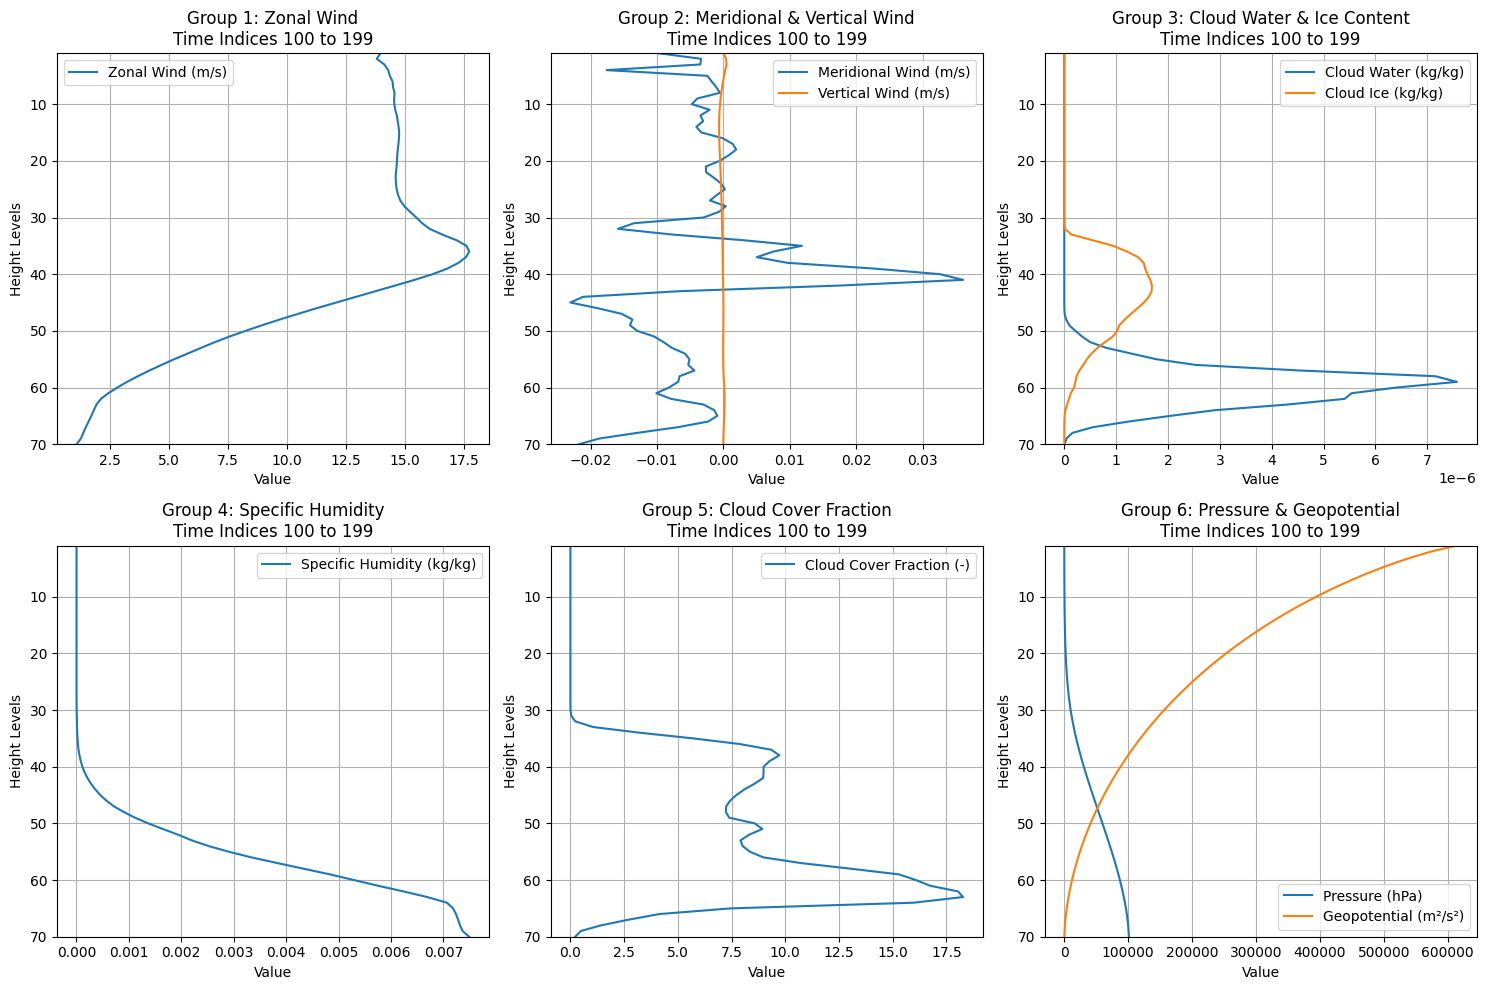

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# Path to your 3D features dataset (replace if needed)
file_tendencies = (
    "../../../../../s3/deepcloud/deepcloud/icon_tendencies/"
    "year1/ml_ecrad_ape_R2B05_myrunscript_1year_183min_"
    "tendencies_inputs_DOM01_ml_0001_lonlat.nc"
)
ds = xr.open_dataset(file_tendencies)

# Define the range of time indices you want to consider
start_time_index = 100   # Starting time index
end_time_index = 200    # Ending time index (exclusive)
time_slice = slice(start_time_index, end_time_index)

num_cells = ds.sizes["ncells"]
num_times = ds.sizes["time"]
print(f"Number of cells: {num_cells}")
print(f"Number of time steps: {num_times}")

# Define your variable groupings
variables_group1 = [
    ("u", "Zonal Wind (m/s)"),
]

variables_group2 = [
    ("v", "Meridional Wind (m/s)"),
    ("w", "Vertical Wind (m/s)"),
]

variables_group3 = [
    ("qc", "Cloud Water (kg/kg)"),
    ("qi", "Cloud Ice (kg/kg)"),
]

variables_group4 = [
    ("qv", "Specific Humidity (kg/kg)"),
]

variables_group5 = [
    ("clc", "Cloud Cover Fraction (-)"),
]

variables_group6 = [
    ("pres", "Pressure (Pa)"),
    ("geopot", "Geopotential (m²/s²)"),
]

# Create a list of all variable groups and their labels
variable_groups = [
    (variables_group1, "Group 1: Zonal Wind"),
    (variables_group2, "Group 2: Meridional & Vertical Wind"),
    (variables_group3, "Group 3: Cloud Water & Ice Content"),
    (variables_group4, "Group 4: Specific Humidity"),
    (variables_group5, "Group 5: Cloud Cover Fraction"),
    (variables_group6, "Group 6: Pressure & Geopotential"),
]

def plot_with_mismatch_fix(ax, data_var, var_label):
    """
    Plot data_var vs. ds["height"] on Axes ax, allowing for
    a mismatch in the vertical dimension size.
    """
    # Identify the vertical dimension in data_var
    vert_dim = None
    for dname in data_var.dims:
        if "height" in dname.lower():
            vert_dim = dname
            break
    if vert_dim is None:
        print(f"Warning: Could not find vertical dimension for '{var_label}'. Skipping plot.")
        return

    # Mean over time and ncells, then apply the time slice
    data_slc = data_var.isel(time=time_slice).mean(dim=["time", "ncells"])

    # Mask zeros
    #mask = data_slc != 0
    #data_slc = data_slc.where(mask, np.nan)

    # Handle dimension mismatch with ds["height"]
    z_size_data = data_slc.sizes[vert_dim]
    z_size_ds = ds["height"].size
    min_z_size = min(z_size_data, z_size_ds)

    # Slice both to the smaller dimension so that x and y match
    data_slc = data_slc.isel({vert_dim: slice(None, min_z_size)})
    height_slc = ds["height"].isel(height=slice(None, min_z_size))

    # Plot
    ax.plot(data_slc, height_slc, label=var_label)

# Determine the layout for 6 subplots (e.g., 2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Flatten to easily iterate over axes

# Iterate over variable groups and corresponding axes
for idx, (var_group, group_title) in enumerate(variable_groups):
    ax = axes[idx]
    for var_name, var_label in var_group:
        if var_name not in ds:
            print(f"Warning: variable '{var_name}' not found in dataset.")
            continue
        plot_with_mismatch_fix(ax, ds[var_name], var_label)

    ax.set_xlabel("Value")
    ax.set_ylabel("Height Levels")
    ax.set_title(f"{group_title}\nTime Indices {start_time_index} to {end_time_index - 1}")
    ax.set_ylim(ds["height"].min(), ds["height"].max())
    ax.invert_yaxis()
    ax.legend()
    ax.grid(True)

# Hide any unused subplots if there are any
if len(axes) > len(variable_groups):
    for ax in axes[len(variable_groups):]:
        ax.axis('off')

plt.tight_layout()
plt.show()

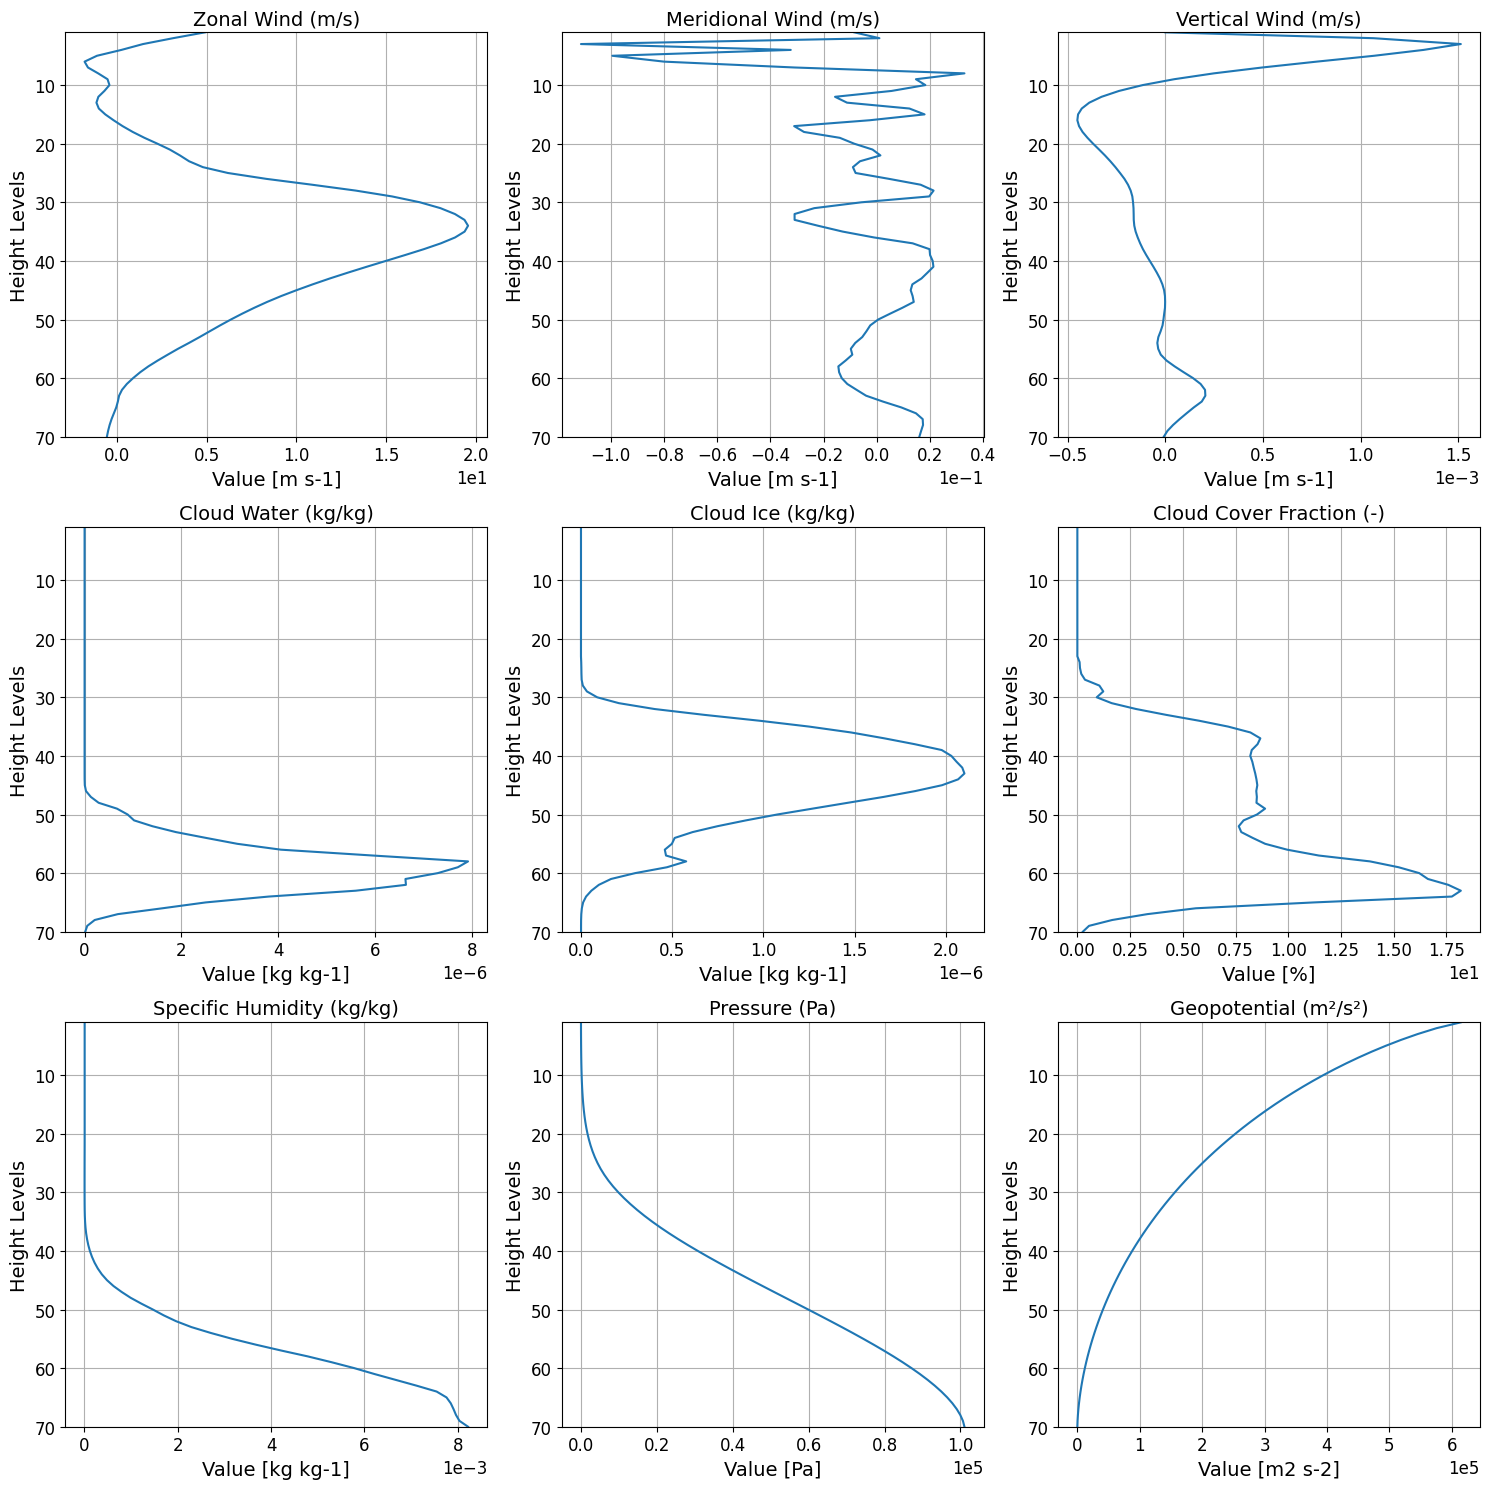

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pickle

###############################################################################
# 1. BUILD LIST OF YEAR FOLDERS & RANDOMLY SAMPLE FROM EACH FILE
###############################################################################
base_path = "/s3/deepcloud/deepcloud/icon_tendencies/"
file_name = (
    "ml_ecrad_ape_R2B05_myrunscript_1year_183min_"
    "tendencies_inputs_DOM01_ml_0001_lonlat.nc"
)
# Folder names: year1, year2, ..., year12
folders = [f"year{i}" for i in range(1, 13)]

filepaths = [os.path.join(base_path, folder, file_name) for folder in folders]

# Decide how many total random time steps you want, e.g., 240 => 20 per file
N_total = 120
samples_per_file = N_total // 12  # 20 per file if N_total=240

sampled_datasets = []
for fp in filepaths:
    #print(f"Sampling from file: {fp}")
    ds_month = xr.open_dataset(fp, chunks={"time": 1})  # lazy load each file
    n_times = ds_month.sizes["time"]

    # Randomly pick time indices
    rand_inds = np.random.choice(n_times, size=samples_per_file, replace=False)
    rand_inds = np.sort(rand_inds)  # optional but keeps ascending time order

    # Subset the dataset
    ds_subset = ds_month.isel(time=rand_inds)
    ds_month.close()  # close file

    sampled_datasets.append(ds_subset)

# Concatenate all subsets along "time"
ds = xr.concat(sampled_datasets, dim="time")


###############################################################################
# 2) LOAD NORMALIZATION STATISTICS (REMOVED)
###############################################################################
# Since normalization is not required, this section is removed.

###############################################################################
# 3) DEFINE VARIABLES WE WANT TO PLOT
###############################################################################
variables = [
    ("u", "Zonal Wind (m/s)"),
    ("v", "Meridional Wind (m/s)"),
    ("w", "Vertical Wind (m/s)"),
    ("qc", "Cloud Water (kg/kg)"),
    ("qi", "Cloud Ice (kg/kg)"),
    ("clc", "Cloud Cover Fraction (-)"),
    ("qv", "Specific Humidity (kg/kg)"),
    ("pres", "Pressure (Pa)"),
    ("geopot", "Geopotential (m²/s²)"),
]

###############################################################################
# 4) FUNCTION TO PLOT RAW PROFILES
###############################################################################
def plot_profile(ax, data_var, var_label):
    """
    Plot raw data_var vs. ds["height"] on Axes ax.
    data_var: xarray DataArray (time, ncells, height) or similar
    var_label: string for the plot label
    """
    # Identify the vertical dimension in data_var
    vert_dim = None
    for dname in data_var.dims:
        if "height" in dname.lower():
            vert_dim = dname
            break
    if vert_dim is None:
        print(f"Warning: Could not find vertical dimension for '{var_label}'. Skipping plot.")
        return

    # Mean over time and ncells
    data_slc = data_var.mean(dim=["time", "ncells"])

    # Handle dimension mismatch with ds["height"] 
    z_size_data = data_slc.sizes[vert_dim]
    z_size_ds   = ds["height"].size
    min_z_size  = min(z_size_data, z_size_ds)

    # Slice both to the smaller dimension so that x and y match
    data_slc = data_slc.isel({vert_dim: slice(None, min_z_size)})
    height_slc = ds["height"].isel(height=slice(None, min_z_size))

    # Plot
    ax.plot(data_slc, height_slc, label=var_label)
    
    # Set x-axis tick labels to scientific notation
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

    # Increase the font size of the scientific notation
    ax.xaxis.get_offset_text().set_fontsize(12)

###############################################################################
# 5) CREATE SUBPLOTS AND PLOT EACH VARIABLE
###############################################################################
num_vars = len(variables)
num_rows = (num_vars + 2) // 3
num_cols = 3
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()

for idx, (var_name, var_label) in enumerate(variables):
    ax = axes[idx]
    if var_name not in ds:
        print(f"Warning: variable '{var_name}' not found in dataset.")
        continue

    plot_profile(ax, ds[var_name], var_label)

    # Get the units from the DataArray
    units = ds[var_name].attrs.get('units', '')

    ax.set_xlabel(f"Value [{units}]", fontsize=14)  # Include units in x-label
    ax.set_ylabel("Height Levels", fontsize=14)
    ax.set_title(var_label, fontsize=14)  # Remove N_total from title
    ax.set_ylim(ds["height"].min(), ds["height"].max())
    ax.invert_yaxis()
    ax.grid(True)
    
    # Increase tick label size
    ax.tick_params(axis='both', which='major', labelsize=12)

# Hide any unused subplots
if len(axes) > num_vars:
    for ax in axes[num_vars:]:
        ax.axis('off')

plt.tight_layout()
plt.show()

### Normalized Input Across all 12 Files

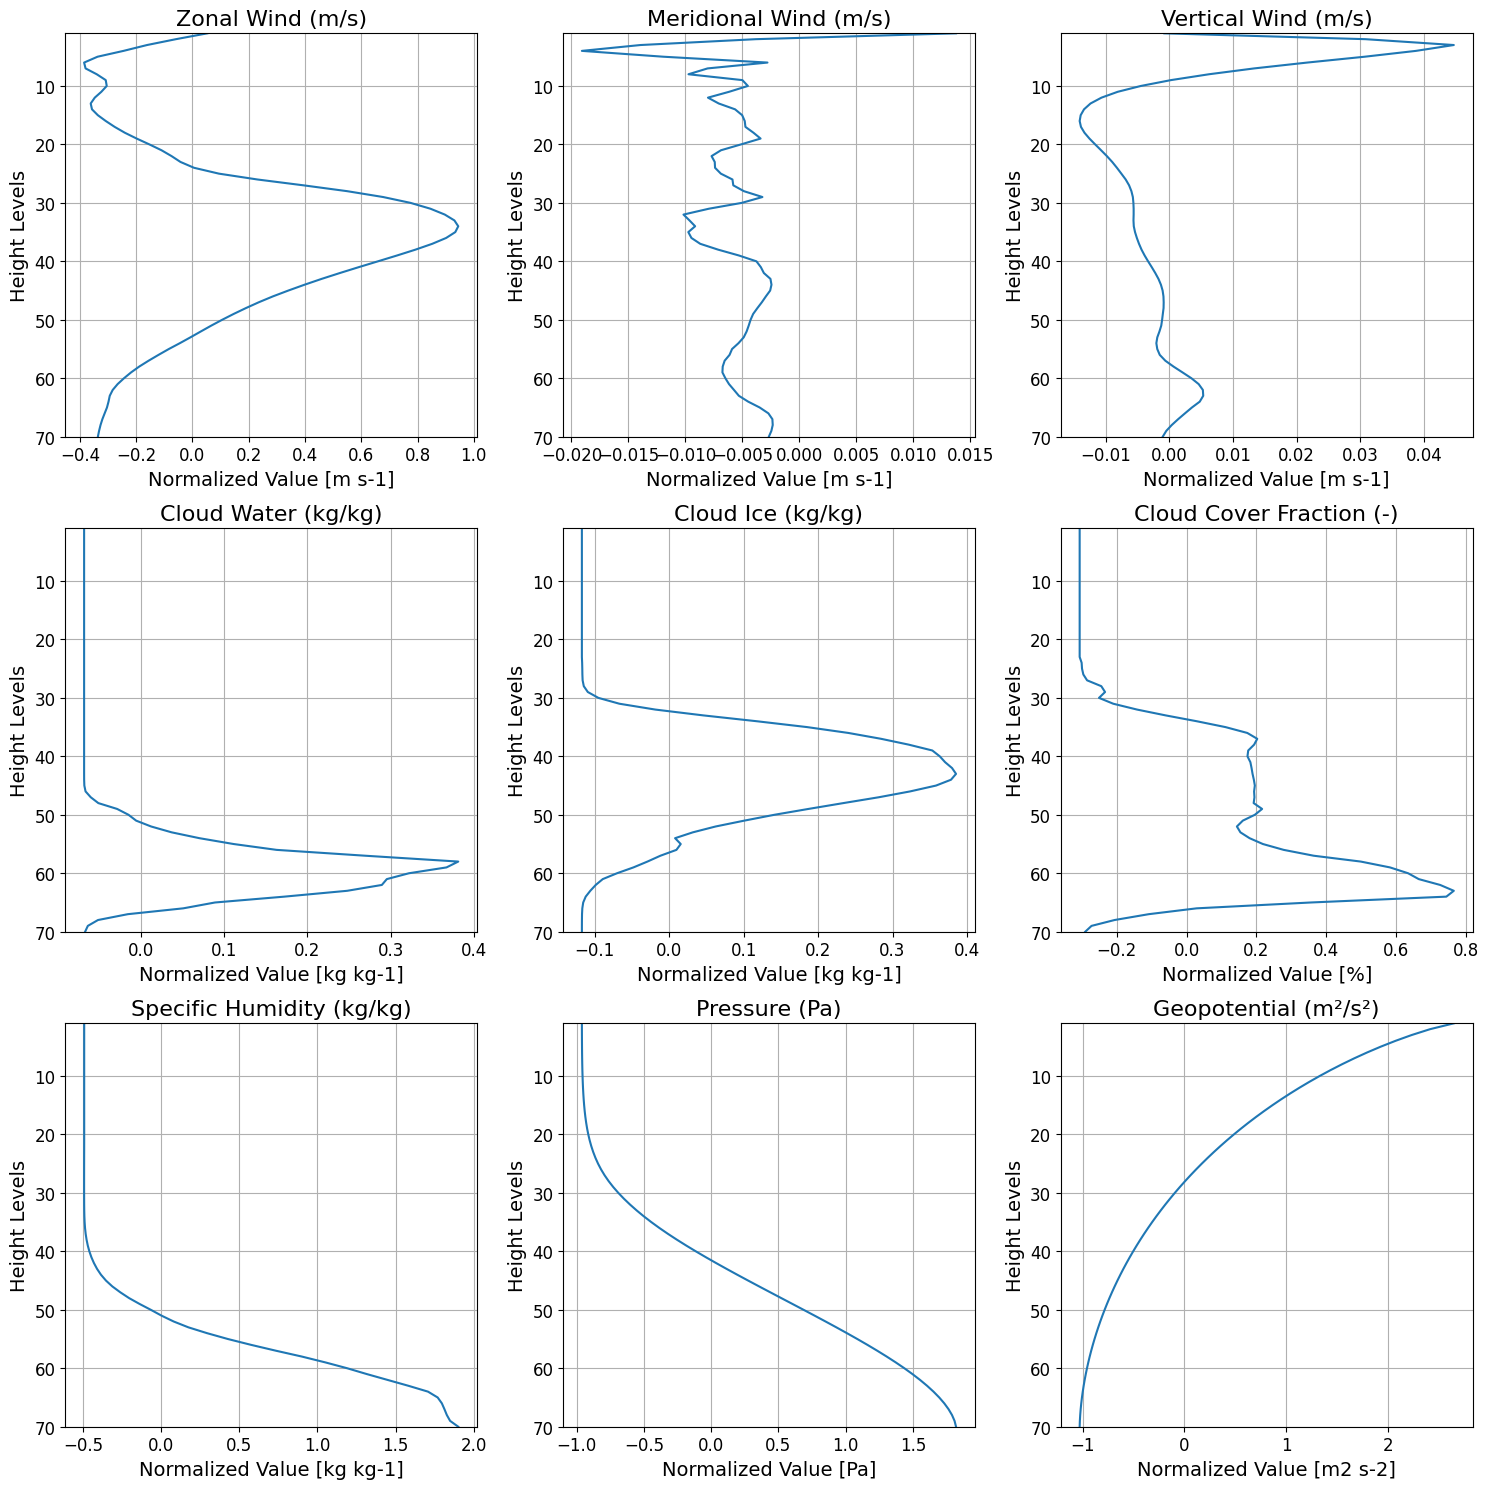

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import torch
import pickle

###############################################################################
# 1. BUILD LIST OF YEAR FOLDERS & RANDOMLY SAMPLE FROM EACH FILE
###############################################################################
base_path = "/s3/deepcloud/deepcloud/icon_tendencies/"
file_name = (
    "ml_ecrad_ape_R2B05_myrunscript_1year_183min_"
    "tendencies_inputs_DOM01_ml_0001_lonlat.nc"
)
# Folder names: year1, year2, ..., year12
folders = [f"year{i}" for i in range(1, 13)]

filepaths = [os.path.join(base_path, folder, file_name) for folder in folders]

# Decide how many total random time steps you want, e.g. 240 => 20 per file
N_total = 120
samples_per_file = N_total // 12

sampled_datasets = []
for fp in filepaths:
    # print(f"Sampling from file: {fp}")
    ds_month = xr.open_dataset(fp, chunks={"time": 1})  # lazy load each big file

    n_times = ds_month.sizes["time"]
    # print(f"  -> This file has {n_times} timesteps.")

    # Randomly pick time indices
    rand_inds = np.random.choice(n_times, size=samples_per_file, replace=False)
    rand_inds = np.sort(rand_inds)  # optional but keeps ascending time order

    ds_subset = ds_month.isel(time=rand_inds)
    ds_month.close()  # close big file

    sampled_datasets.append(ds_subset)

# Concatenate all subsets along "time"
ds = xr.concat(sampled_datasets, dim="time")
# print("Final concatenated dataset (ds) dimensions:\n", ds)


###############################################################################
# 2) LOAD NORMALIZATION STATISTICS
###############################################################################
stats_file = '/mydata/deepcloud/shared/h5_tendency_all/normalizer_stats_per_feat_updated1.pickle'
with open(stats_file, 'rb') as f:
    stats = pickle.load(f)

mean2d = torch.tensor(stats['mean2d']).float()
var2d  = torch.tensor(stats['var2d']).float()
mean3d = torch.tensor(stats['mean3d']).float()
var3d  = torch.tensor(stats['var3d']).float()
std2d  = torch.sqrt(var2d)
std3d  = torch.sqrt(var3d)

# Map variable names to their indices in the statistics arrays
stats_variables = [
    'u',        # 0
    'v',        # 1
    'geopot',   # 2
    'pres',     # 3
    'clc',      # 4
    'qc',       # 5
    'qi',       # 6
    'qv',       # 7
    'temp',     # 8
    'w'         # 9
]
variable_to_index = {name: idx for idx, name in enumerate(stats_variables)}

###############################################################################
# 3) DEFINE VARIABLES WE WANT TO PLOT
###############################################################################
variables = [
    ("u", "Zonal Wind (m/s)"),
    ("v", "Meridional Wind (m/s)"),
    ("w", "Vertical Wind (m/s)"),
    ("qc", "Cloud Water (kg/kg)"),
    ("qi", "Cloud Ice (kg/kg)"),
    ("clc", "Cloud Cover Fraction (-)"),
    ("qv", "Specific Humidity (kg/kg)"),
    ("pres", "Pressure (Pa)"),
    ("geopot", "Geopotential (m²/s²)"),
]

###############################################################################
# 4) FUNCTION TO PLOT NORMALIZED PROFILES
###############################################################################
def plot_with_normalization(ax, data_var, var_label, var_name):
    """
    Plot normalized data_var vs. ds["height"] on Axes ax.
    data_var: xarray DataArray (time, ncells, height) or similar
    var_label: string for the plot label
    var_name: variable shortname for stats lookup
    """

    # Identify the vertical dimension in data_var
    vert_dim = None
    for dname in data_var.dims:
        if "height" in dname.lower():
            vert_dim = dname
            break
    if vert_dim is None:
        print(f"Warning: Could not find vertical dimension for '{var_label}'. Skipping plot.")
        return

    # Mean over time and ncells
    data_slc = data_var.mean(dim=["time", "ncells"])

    # Retrieve mean and std for normalization
    if var_name in variable_to_index:
        idx = variable_to_index[var_name]
        mean_val = mean3d[idx].item()
        std_val = std3d[idx].item()
        if std_val == 0:
            std_val = 1e-6  # avoid division by zero
    else:
        print(f"Warning: No statistics found for '{var_name}'. Skipping normalization for this variable.")
        mean_val, std_val = 0.0, 1.0

    # Apply normalization
    data_normalized = (data_slc - mean_val) / std_val

    # Handle dimension mismatch with ds["height"] 
    z_size_data = data_normalized.sizes[vert_dim]
    z_size_ds   = ds["height"].size
    min_z_size  = min(z_size_data, z_size_ds)

    # Slice both to the smaller dimension so that x and y match
    data_normalized = data_normalized.isel({vert_dim: slice(None, min_z_size)})
    height_slc      = ds["height"].isel(height=slice(None, min_z_size))

    # Plot
    ax.plot(data_normalized, height_slc, label=var_label)

###############################################################################
# 5) CREATE SUBPLOTS AND PLOT EACH VARIABLE
###############################################################################
num_vars = len(variables)
num_rows = (num_vars + 2) // 3
num_cols = 3
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()

for idx, (var_name, var_label) in enumerate(variables):
    ax = axes[idx]
    if var_name not in ds:
        print(f"Warning: variable '{var_name}' not found in dataset.")
        continue

    plot_with_normalization(ax, ds[var_name], var_label, var_name)

    # Get the units from the DataArray
    units = ds[var_name].attrs.get('units', '')

    ax.set_xlabel(f"Normalized Value [{units}]", fontsize=14)  # Include units in x-label
    ax.set_ylabel("Height Levels", fontsize=14)
    ax.set_title(var_label, fontsize=16)  # Remove N_total from title
    ax.set_ylim(ds["height"].min(), ds["height"].max())
    ax.invert_yaxis()
    ax.grid(True)
    
    # Increase tick label size
    ax.tick_params(axis='both', which='major', labelsize=12)

# Hide any unused subplots
if len(axes) > num_vars:
    for ax in axes[num_vars:]:
        ax.axis('off')

plt.tight_layout()
plt.show()


### Targets values mean of first 100 timesteps of the first months over all space

Number of cells: 81920
Number of time steps: 240


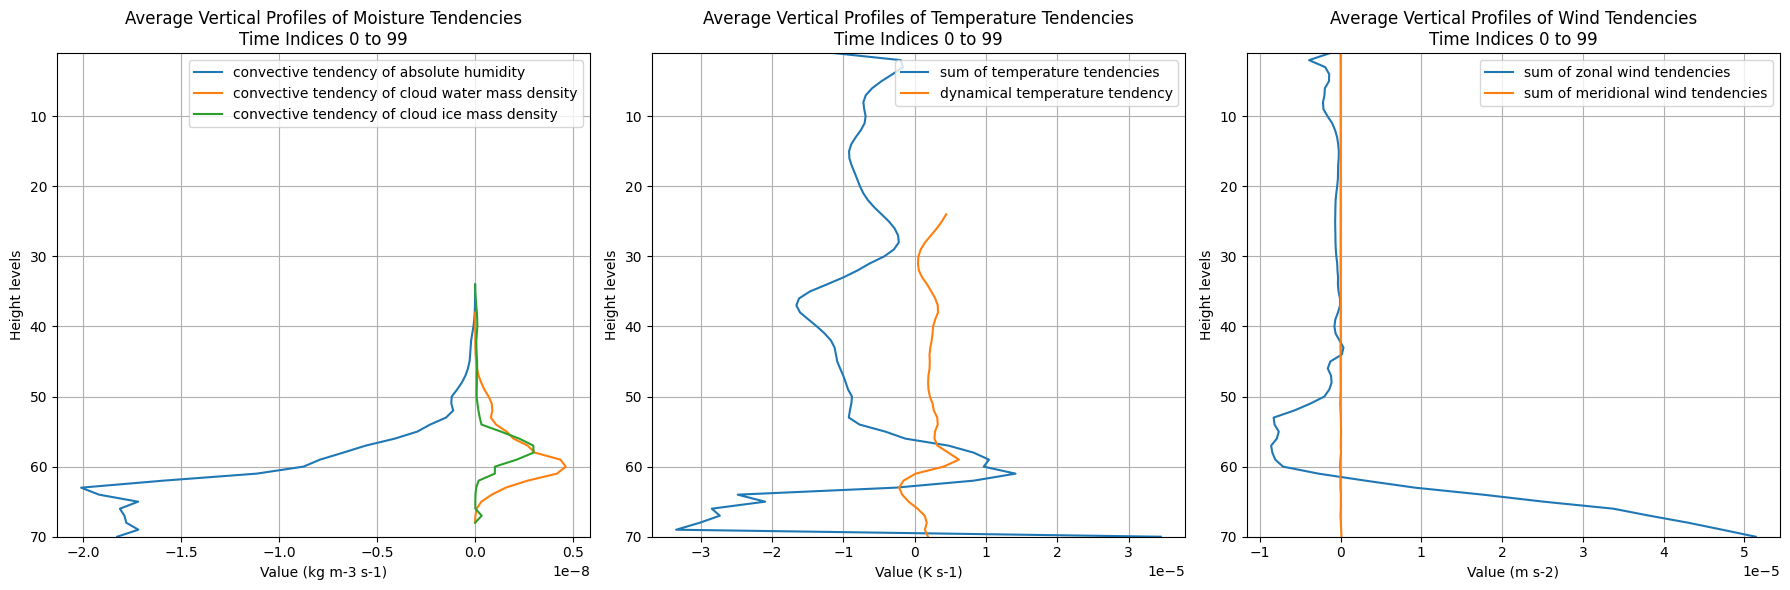

In [23]:

import os
import matplotlib.pyplot as plt
import xarray as xr

file_tendencies = '../../../../../s3/deepcloud/deepcloud/icon_tendencies/year1/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_DOM01_ml_0001_lonlat.nc'
ds = xr.open_dataset(file_tendencies)

# Define the range of time indices you want to consider
start_time_index = 0   # Starting time index
end_time_index = 100   # Ending time index (exclusive, so this goes up to index 299)

# Use a time slice to select the range of time indices
time_slice = slice(start_time_index, end_time_index)

# Plot over all cells and the specified time range
num_cells = ds.sizes['ncells']
num_times = ds.sizes['time']
print(f"Number of cells: {num_cells}")
print(f"Number of time steps: {num_times}")

variables1 = ['ddt_qv_conv', 'ddt_qc_conv', 'ddt_qi_conv']
variables2 = ['ddt_temp_sum', 'ddt_temp_dyn']
variables3 = ['ddt_u_sum', 'ddt_v_sum']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Moisture Tendencies
units1 = ds[variables1[0]].attrs.get('units', '')
for var in variables1:
    long_name = ds[var].attrs.get('long_name', var)
    # Select the desired time range and compute the mean over time and cells
    data = ds[var].isel(time=time_slice).mean(dim=['time', 'ncells'])
    mask = data != 0  # Mask to exclude zero values
    ax1.plot(data.where(mask, np.nan), ds['height'], label=long_name)

ax1.set_xlabel(f'Value ({units1})')
ax1.set_ylabel('Height levels')
ax1.set_title(f'Average Vertical Profiles of Moisture Tendencies\nTime Indices {start_time_index} to {end_time_index - 1}')
ax1.set_ylim(ds['height'].min(), ds['height'].max())
ax1.invert_yaxis()
ax1.legend()
ax1.grid(True)

# Plot 2: Temperature Tendencies
units2 = ds[variables2[0]].attrs.get('units', '')
for var in variables2:
    long_name = ds[var].attrs.get('long_name', var)
    data = ds[var].isel(time=time_slice).mean(dim=['time', 'ncells'])
    mask = data != 0
    ax2.plot(data.where(mask, np.nan), ds['height'], label=long_name)

ax2.set_xlabel(f'Value ({units2})')
ax2.set_ylabel('Height levels')
ax2.set_title(f'Average Vertical Profiles of Temperature Tendencies\nTime Indices {start_time_index} to {end_time_index - 1}')
ax2.set_ylim(ds['height'].min(), ds['height'].max())
ax2.invert_yaxis()
ax2.legend()
ax2.grid(True)

# Plot 3: Wind Tendencies
units3 = ds[variables3[0]].attrs.get('units', '')
for var in variables3:
    long_name = ds[var].attrs.get('long_name', var)
    data = ds[var].isel(time=time_slice).mean(dim=['time', 'ncells'])
    mask = data != 0
    ax3.plot(data.where(mask, np.nan), ds['height'], label=long_name)

ax3.set_xlabel(f'Value ({units3})')
ax3.set_ylabel('Height levels')
ax3.set_title(f'Average Vertical Profiles of Wind Tendencies\nTime Indices {start_time_index} to {end_time_index - 1}')
ax3.set_ylim(ds['height'].min(), ds['height'].max())
ax3.invert_yaxis()
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

### normalized target values for 100 samples over time of the first month over all space an time

Number of cells: 81920
Number of time steps: 240
Shape of ddt_temp_sum: (70,)
Shape of ddt_temp_dyn: (70,)
Shape of ddt_u_sum: (70,)
Shape of ddt_v_sum: (70,)


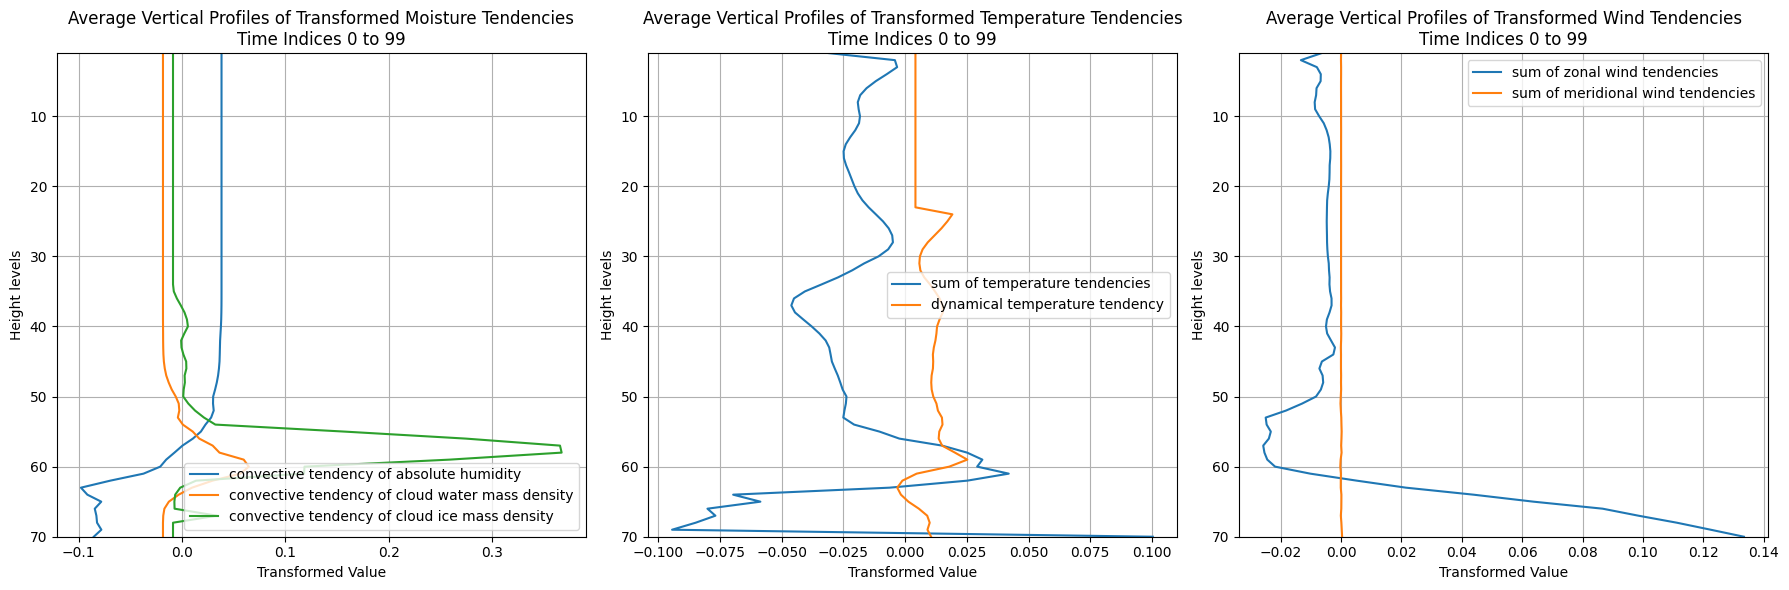

In [32]:
import os
import matplotlib.pyplot as plt
import xarray as xr
import pickle
import numpy as np

file_tendencies = '../../../../../s3/deepcloud/deepcloud/icon_tendencies/year1/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_DOM01_ml_0001_lonlat.nc'
ds = xr.open_dataset(file_tendencies)

# Define the range of time indices you want to consider
start_time_index = 0   # Starting time index
end_time_index = 100   # Ending time index (exclusive, so this goes up to index 299)

# Use a time slice to select the range of time indices
time_slice = slice(start_time_index, end_time_index)

# Plot over all cells and the specified time range
num_cells = ds.sizes['ncells']
num_times = ds.sizes['time']
print(f"Number of cells: {num_cells}")
print(f"Number of time steps: {num_times}")

variables1 = ['ddt_qv_conv', 'ddt_qc_conv', 'ddt_qi_conv']
variables2 = ['ddt_temp_sum', 'ddt_temp_dyn']
variables3 = ['ddt_u_sum', 'ddt_v_sum']

# Load target statistics
target_stats_file = '/mydata/deepcloud/shared/h5_tendency_all/normalizer_stats_per_feat_y2_no_temp.pickle'
with open(target_stats_file, 'rb') as f:
    target_stats = pickle.load(f)

target_means = np.array(target_stats['mean'])  # Shape: (num_features,)
target_vars = np.array(target_stats['var'])    # Shape: (num_features,)

def transform_data(data, mean, variance, k=4, min_scale=1e-6):
    # data: numpy array of shape (num_levels,)
    # mean: scalar value
    # variance: scalar value
    
    # Compute standard deviation
    std_dev = np.sqrt(variance)
    
    # Compute scaling factor
    scale_factor = k * std_dev
    # scale_factor = np.clip(scale_factor, a_min=min_scale, a_max=None)
    
    # Transform data
    data_transformed = (data - mean) / scale_factor
    
    return data_transformed

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Moisture Tendencies
units1 = ds[variables1[0]].attrs.get('units', '')
for var in variables1:
    long_name = ds[var].attrs.get('long_name', var)
    # Select the desired time range and compute the mean over time and cells
    data = ds[var].isel(time=time_slice).mean(dim=['time', 'ncells'])
    #print(f"Shape of {var}: {data.shape}")
    mask = data != 0  # Mask to exclude zero values
    
    # Transform the data using the target statistics for the corresponding feature
    if var == 'ddt_qv_conv':
        data_transformed = transform_data(data.values, target_means[4], target_vars[4])
    elif var == 'ddt_qc_conv':
        data_transformed = transform_data(data.values, target_means[5], target_vars[5])
    elif var == 'ddt_qi_conv':
        data_transformed = transform_data(data.values, target_means[6], target_vars[6])
    
    ax1.plot(data_transformed, ds['height'], label=long_name)

ax1.set_xlabel(f'Transformed Value')
ax1.set_ylabel('Height levels')
ax1.set_title(f'Average Vertical Profiles of Transformed Moisture Tendencies\nTime Indices {start_time_index} to {end_time_index - 1}')
ax1.set_ylim(ds['height'].min(), ds['height'].max())
ax1.invert_yaxis()
ax1.legend()
ax1.grid(True)

# Plot 2: Temperature Tendencies
units2 = ds[variables2[0]].attrs.get('units', '')
for var in variables2:
    long_name = ds[var].attrs.get('long_name', var)
    data = ds[var].isel(time=time_slice).mean(dim=['time', 'ncells'])
    print(f"Shape of {var}: {data.shape}")
    mask = data != 0
    
    # Transform the data using the target statistics for the corresponding feature
    if var == 'ddt_temp_sum':
        data_transformed = transform_data(data.values, target_means[0], target_vars[0])
    elif var == 'ddt_temp_dyn':
        data_transformed = transform_data(data.values, target_means[1], target_vars[1])
    
    ax2.plot(data_transformed, ds['height'], label=long_name)

ax2.set_xlabel(f'Transformed Value')
ax2.set_ylabel('Height levels')
ax2.set_title(f'Average Vertical Profiles of Transformed Temperature Tendencies\nTime Indices {start_time_index} to {end_time_index - 1}')
ax2.set_ylim(ds['height'].min(), ds['height'].max())
ax2.invert_yaxis()
ax2.legend()
ax2.grid(True)

# Plot 3: Wind Tendencies
units3 = ds[variables3[0]].attrs.get('units', '')
for var in variables3:
    long_name = ds[var].attrs.get('long_name', var)
    data = ds[var].isel(time=time_slice).mean(dim=['time', 'ncells'])
    print(f"Shape of {var}: {data.shape}")
    mask = data != 0
    
    # Transform the data using the target statistics for the corresponding feature
    if var == 'ddt_u_sum':
        data_transformed = transform_data(data.values, target_means[2], target_vars[2])
    elif var == 'ddt_v_sum':
        data_transformed = transform_data(data.values, target_means[3], target_vars[3])
    
    ax3.plot(data_transformed, ds['height'], label=long_name)

ax3.set_xlabel(f'Transformed Value')
ax3.set_ylabel('Height levels')
ax3.set_title(f'Average Vertical Profiles of Transformed Wind Tendencies\nTime Indices {start_time_index} to {end_time_index - 1}')
ax3.set_ylim(ds['height'].min(), ds['height'].max())
ax3.invert_yaxis()
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

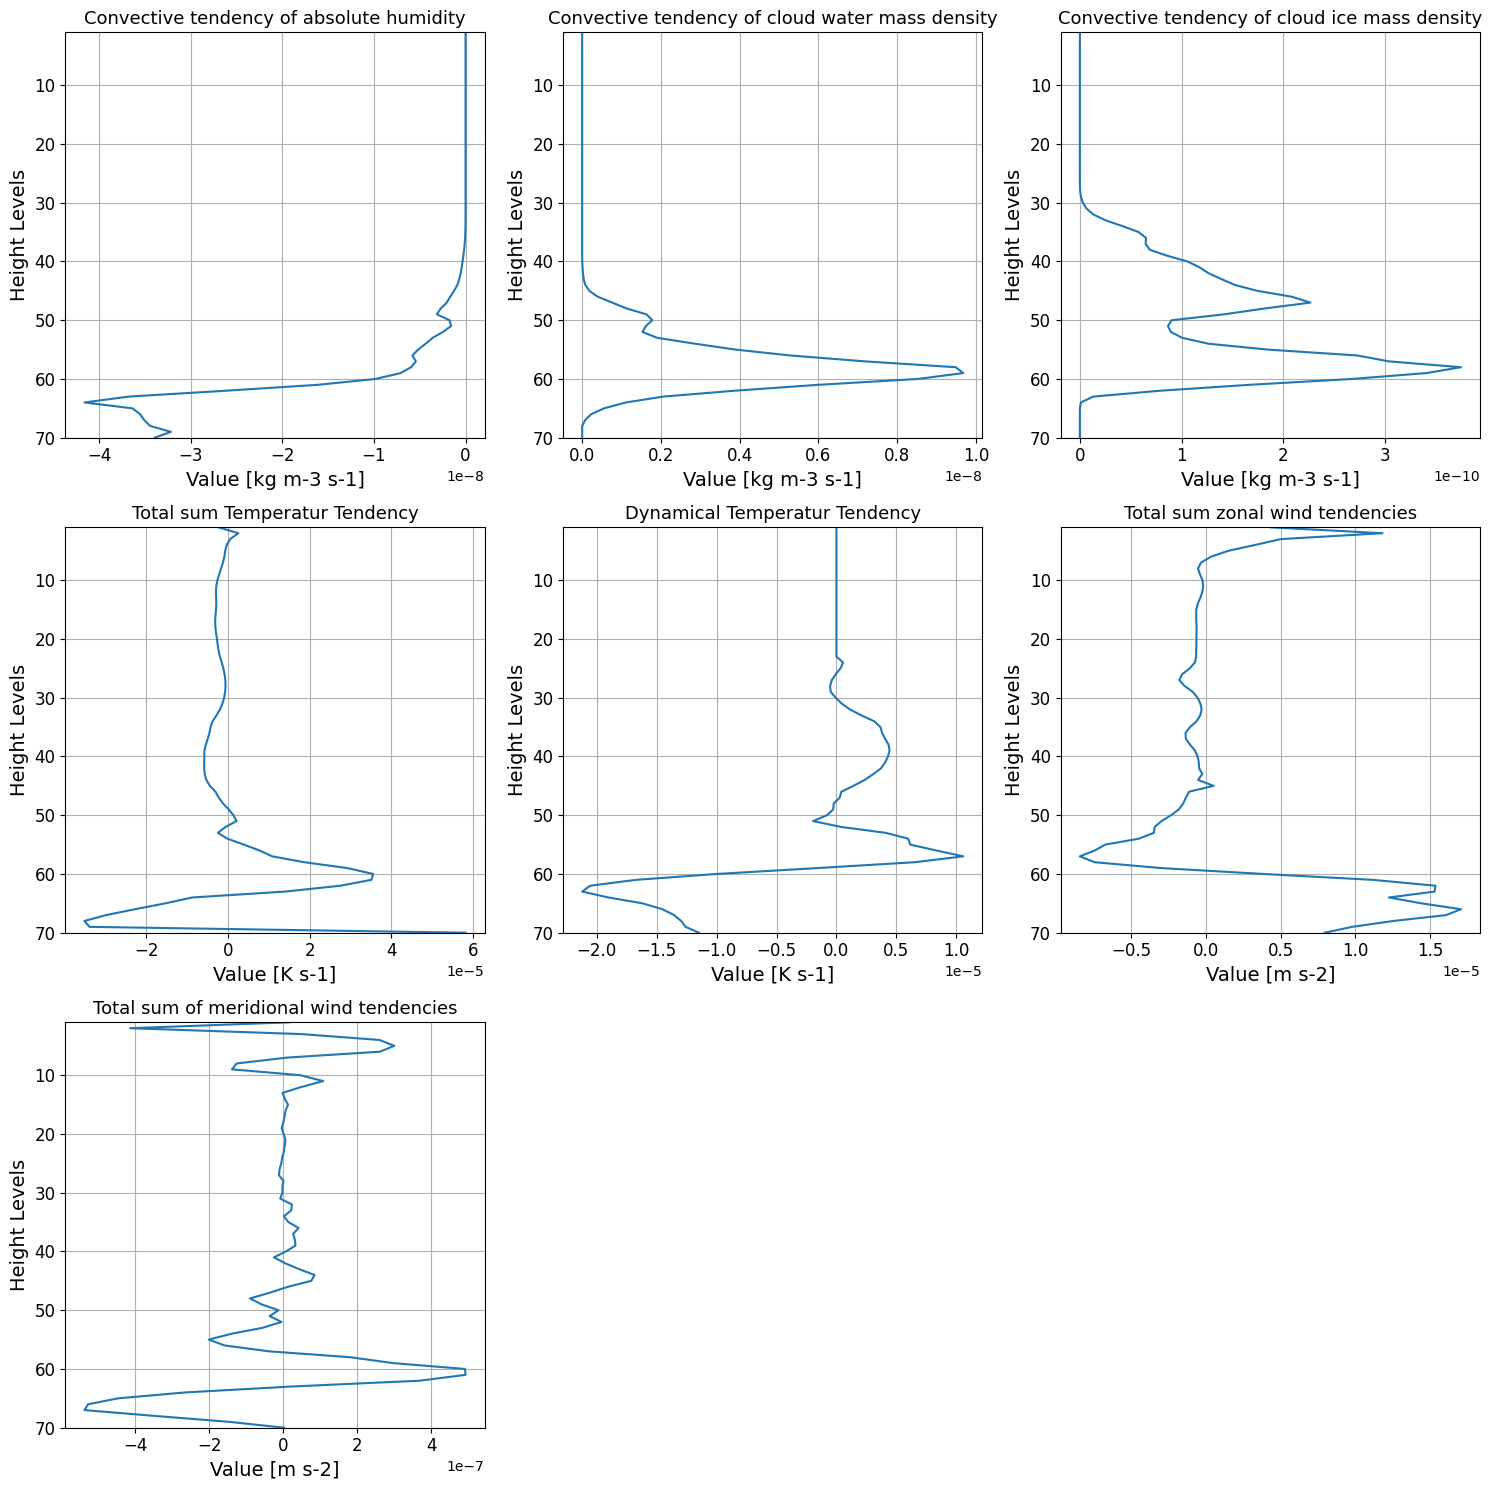

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pickle

###############################################################################
# 1. BUILD LIST OF YEAR FOLDERS & RANDOMLY SAMPLE FROM EACH FILE
###############################################################################
base_path = "/s3/deepcloud/deepcloud/icon_tendencies/"
file_name = (
    "ml_ecrad_ape_R2B05_myrunscript_1year_183min_"
    "tendencies_DOM01_ml_0001_lonlat.nc"
)
# Folder names: year1, year2, ..., year12
folders = [f"year{i}" for i in range(1, 13)]

filepaths = [os.path.join(base_path, folder, file_name) for folder in folders]

# Decide how many total random time steps you want, e.g., 240 => 20 per file
N_total = 120
samples_per_file = N_total // 12  # 20 per file if N_total=240

sampled_datasets = []
for fp in filepaths:
    #print(f"Sampling from file: {fp}")
    ds_month = xr.open_dataset(fp, chunks={"time": 1})  # lazy load each file
    n_times = ds_month.sizes["time"]

    # Randomly pick time indices
    rand_inds = np.random.choice(n_times, size=samples_per_file, replace=False)
    rand_inds = np.sort(rand_inds)  # optional but keeps ascending time order

    # Subset the dataset
    ds_subset = ds_month.isel(time=rand_inds)
    ds_month.close()  # close file

    sampled_datasets.append(ds_subset)

# Concatenate all subsets along "time"
ds = xr.concat(sampled_datasets, dim="time")


###############################################################################
# 2) LOAD NORMALIZATION STATISTICS (REMOVED)
###############################################################################
# Since normalization is not required, this section is removed.

###############################################################################
# 3) DEFINE VARIABLES WE WANT TO PLOT
###############################################################################
variables = [
    ("ddt_qv_conv",  "Convective tendency of absolute humidity"),
    ("ddt_qc_conv",  "Convective tendency of cloud water mass density"),
    ("ddt_qi_conv",  "Convective tendency of cloud ice mass density"),
    ("ddt_temp_sum", "Total sum Temperatur Tendency"),
    ("ddt_temp_dyn", "Dynamical Temperatur Tendency"),
    ("ddt_u_sum",    "Total sum zonal wind tendencies"),
    ("ddt_v_sum",    "Total sum of meridional wind tendencies"),
]

###############################################################################
# 4) FUNCTION TO PLOT RAW PROFILES
###############################################################################
def plot_profile(ax, data_var, var_label):
    """
    Plot raw data_var vs. ds["height"] on Axes ax.
    data_var: xarray DataArray (time, ncells, height) or similar
    var_label: string for the plot label
    """
    # Identify the vertical dimension in data_var
    vert_dim = None
    for dname in data_var.dims:
        if "height" in dname.lower():
            vert_dim = dname
            break
    if vert_dim is None:
        print(f"Warning: Could not find vertical dimension for '{var_label}'. Skipping plot.")
        return

    # Mean over time and ncells
    data_slc = data_var.mean(dim=["time", "ncells"])

    # Handle dimension mismatch with ds["height"] 
    z_size_data = data_slc.sizes[vert_dim]
    z_size_ds   = ds["height"].size
    min_z_size  = min(z_size_data, z_size_ds)

    # Slice both to the smaller dimension so that x and y match
    data_slc = data_slc.isel({vert_dim: slice(None, min_z_size)})
    height_slc = ds["height"].isel(height=slice(None, min_z_size))

    # Plot
    ax.plot(data_slc, height_slc, label=var_label)
    
        # Set x-axis tick labels to scientific notation
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

    # Increase the font size of the scientific notation
    ax.xaxis.get_offset_text().set_fontsize(12)

###############################################################################
# 5) CREATE A SINGLE FIGURE WITH SUBPLOTS FOR EACH VARIABLE
###############################################################################
num_vars = len(variables)
num_rows = (num_vars + 2) // 3  # Adjust rows based on number of variables
num_cols = 3  # Fixed number of columns

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()  # Flatten to easily iterate over axes

for idx, (var_name, var_label) in enumerate(variables):
    ax = axes[idx]
    if var_name not in ds:
        print(f"Warning: variable '{var_name}' not found in dataset.")
        ax.set_axis_off()
        continue

    plot_profile(ax, ds[var_name], var_label)

    # Get the units from the DataArray
    units = ds[var_name].attrs.get('units', '')

    ax.set_xlabel(f"Value [{units}]", fontsize=14)  # Include units in x-label
    ax.set_ylabel("Height Levels", fontsize=14)
    ax.set_title(var_label, fontsize=13)  # Remove N_total from title
    ax.set_ylim(ds["height"].min(), ds["height"].max())
    ax.invert_yaxis()
    ax.grid(True)
    
    # Increase tick label size
    ax.tick_params(axis='both', which='major', labelsize=12)

# Hide any remaining unused subplots
if len(axes) > num_vars:
    for ax in axes[num_vars:]:
        ax.axis('off')

plt.tight_layout()
plt.show()


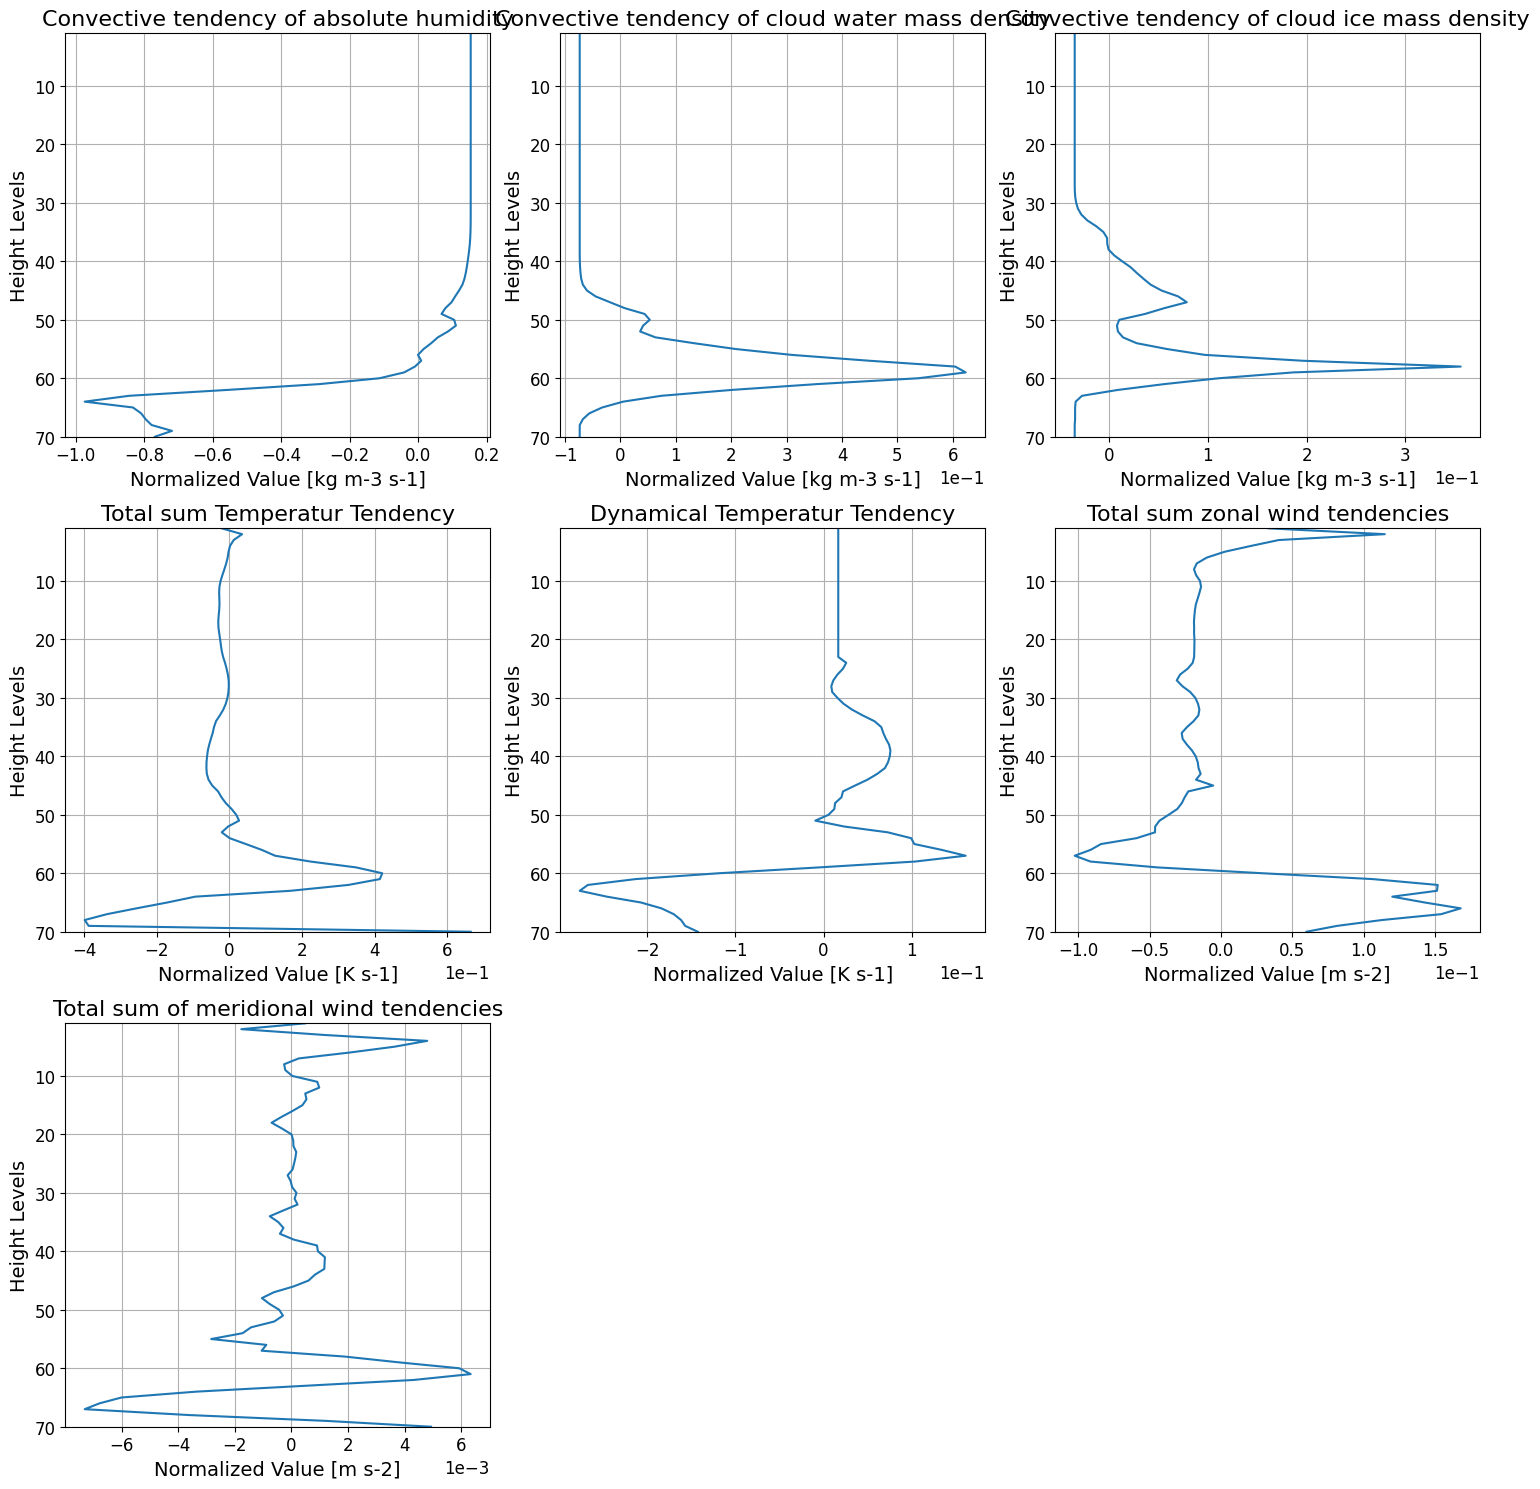

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import torch
import pickle

###############################################################################
# 1. BUILD LIST OF YEAR FOLDERS & RANDOMLY SAMPLE FROM EACH FILE
###############################################################################
base_path = "/s3/deepcloud/deepcloud/icon_tendencies/"
file_name = (
    "ml_ecrad_ape_R2B05_myrunscript_1year_183min_"
    "tendencies_DOM01_ml_0001_lonlat.nc"
)
# Folder names: year1, year2, ..., year12
folders = [f"year{i}" for i in range(1, 13)]

filepaths = [os.path.join(base_path, folder, file_name) for folder in folders]

# Decide how many total random time steps you want, e.g. 240 => 20 per file
N_total = 120
samples_per_file = N_total // 12

sampled_datasets = []
for fp in filepaths:
    #print(f"Sampling from file: {fp}")
    ds_month = xr.open_dataset(fp, chunks={"time": 1})  # lazy load each big file

    n_times = ds_month.sizes["time"]
    # print(f"  -> This file has {n_times} timesteps.")

    # Randomly pick time indices
    rand_inds = np.random.choice(n_times, size=samples_per_file, replace=False)
    rand_inds = np.sort(rand_inds)  # optional but keeps ascending time order

    ds_subset = ds_month.isel(time=rand_inds)
    ds_month.close()  # close big file

    sampled_datasets.append(ds_subset)

# Concatenate all subsets along "time"
ds = xr.concat(sampled_datasets, dim="time")
#print("Final concatenated dataset (ds) dimensions:\n", ds)


###############################################################################
# 2) LOAD NORMALIZATION STATISTICS
###############################################################################
stats_file = '/mydata/deepcloud/shared/h5_tendency_all/normalizer_stats_per_feat_y2_no_temp.pickle'

with open(stats_file, 'rb') as f:
    stats = pickle.load(f)
    

mean = torch.tensor(stats['mean']).float()
var  = torch.tensor(stats['var']).float()
std  = torch.sqrt(var)

# Map variable names to their indices in the statistics arrays
stats_variables = [
        'ddt_temp_sum',    # 0 sum of temperature tendencies
        'ddt_temp_dyn',    # 1 dynamical temperature tendency
        'ddt_u_sum',       # 2 sum of zonal wind tendencies
        'ddt_v_sum',       # 3 sum of meridional wind tendencies
        'ddt_qv_conv',     # 4 convective tendency of absolute humidity
        'ddt_qc_conv',     # 5 convective tendency of cloud water mass density
        'ddt_qi_conv',     # 6 convective tendency of cloud ice mass density<<
    ]

variable_to_index = {name: idx for idx, name in enumerate(stats_variables)}

###############################################################################
# 3) DEFINE VARIABLES WE WANT TO PLOT
###############################################################################
variables = [
    ("ddt_qv_conv",  "Convective tendency of absolute humidity"),
    ("ddt_qc_conv",  "Convective tendency of cloud water mass density"),
    ("ddt_qi_conv",  "Convective tendency of cloud ice mass density"),
    ("ddt_temp_sum", "Total sum Temperatur Tendency"),
    ("ddt_temp_dyn", "Dynamical Temperatur Tendency"),
    ("ddt_u_sum",    "Total sum zonal wind tendencies"),
    ("ddt_v_sum",    "Total sum of meridional wind tendencies"),
]

###############################################################################
# 4) FUNCTION TO PLOT NORMALIZED PROFILES
###############################################################################
def plot_with_normalization(ax, data_var, var_label, var_name):
    """
    Plot normalized data_var vs. ds["height"] on Axes ax.
    data_var: xarray DataArray (time, ncells, height) or similar
    var_label: string for the plot label
    var_name: variable shortname for stats lookup
    """

    # Identify the vertical dimension in data_var
    vert_dim = None
    for dname in data_var.dims:
        if "height" in dname.lower():
            vert_dim = dname
            break
    if vert_dim is None:
        print(f"Warning: Could not find vertical dimension for '{var_label}'. Skipping plot.")
        return

    # Mean over time and ncells
    data_slc = data_var.mean(dim=["time", "ncells"])

    # Retrieve mean and std for normalization
    if var_name in variable_to_index:
        idx = variable_to_index[var_name]
        mean_val = mean[idx].item()
        std_val = std[idx].item()
        if std_val == 0:
            std_val = 1e-6  # avoid division by zero
    else:
        print(f"Warning: No statistics found for '{var_name}'. Skipping normalization for this variable.")
        mean_val, std_val = 0.0, 1.0

    # Apply normalization
    data_normalized = (data_slc - mean_val) / std_val

    # Handle dimension mismatch with ds["height"] 
    z_size_data = data_normalized.sizes[vert_dim]
    z_size_ds   = ds["height"].size
    min_z_size  = min(z_size_data, z_size_ds)

    # Slice both to the smaller dimension so that x and y match
    data_normalized = data_normalized.isel({vert_dim: slice(None, min_z_size)})
    height_slc      = ds["height"].isel(height=slice(None, min_z_size))

    # Plot
    ax.plot(data_normalized, height_slc, label=var_label)
    
        # Set x-axis tick labels to scientific notation
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

    # Increase the font size of the scientific notation
    ax.xaxis.get_offset_text().set_fontsize(12)

###############################################################################
# 5) CREATE SUBPLOTS AND PLOT EACH VARIABLE
###############################################################################
num_vars = len(variables)
num_rows = (num_vars + 2) // 3
num_cols = 3
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()

for idx, (var_name, var_label) in enumerate(variables):
    ax = axes[idx]
    if var_name not in ds:
        print(f"Warning: variable '{var_name}' not found in dataset.")
        continue

    plot_with_normalization(ax, ds[var_name], var_label, var_name)

    # Get the units from the DataArray
    units = ds[var_name].attrs.get('units', '')

    ax.set_xlabel(f"Normalized Value [{units}]", fontsize=14)  # Include units in x-label
    ax.set_ylabel("Height Levels", fontsize=14)
    ax.set_title(var_label, fontsize=16)  # Remove N_total from title
    ax.set_ylim(ds["height"].min(), ds["height"].max())
    ax.invert_yaxis()
    ax.grid(True)
    
    # Increase tick label size
    ax.tick_params(axis='both', which='major', labelsize=12)

# Hide any unused subplots
if len(axes) > num_vars:
    for ax in axes[num_vars:]:
        ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
file_tendencies = '../../../../../s3/deepcloud/deepcloud/icon_tendencies/year1/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_DOM01_ml_0001_lonlat.nc'

# file_tendencies = '../../../../../s3/deepcloud/deepcloud/icon_tendencies/year1/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_inputs_DOM01_ml_0001_lonlat.nc'
#file_tendencies = '../../../../../s3/deepcloud/deepcloud/icon_tendencies/year2/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_inputs_DOM01_ml_0001_lonlat.nc'

# file_tendencies = '../../../../../s3/deepcloud/deepcloud/icon_tendencies/year1/ml_ecrad_ape_R2B05_myrunscript_1year_183min_tendencies_restart_atm_DOM01_20010207T120000Z.nc'



# Open the dataset
ds = xr.open_dataset(file_tendencies)

# size
file_size = os.path.getsize(file_tendencies)


: 

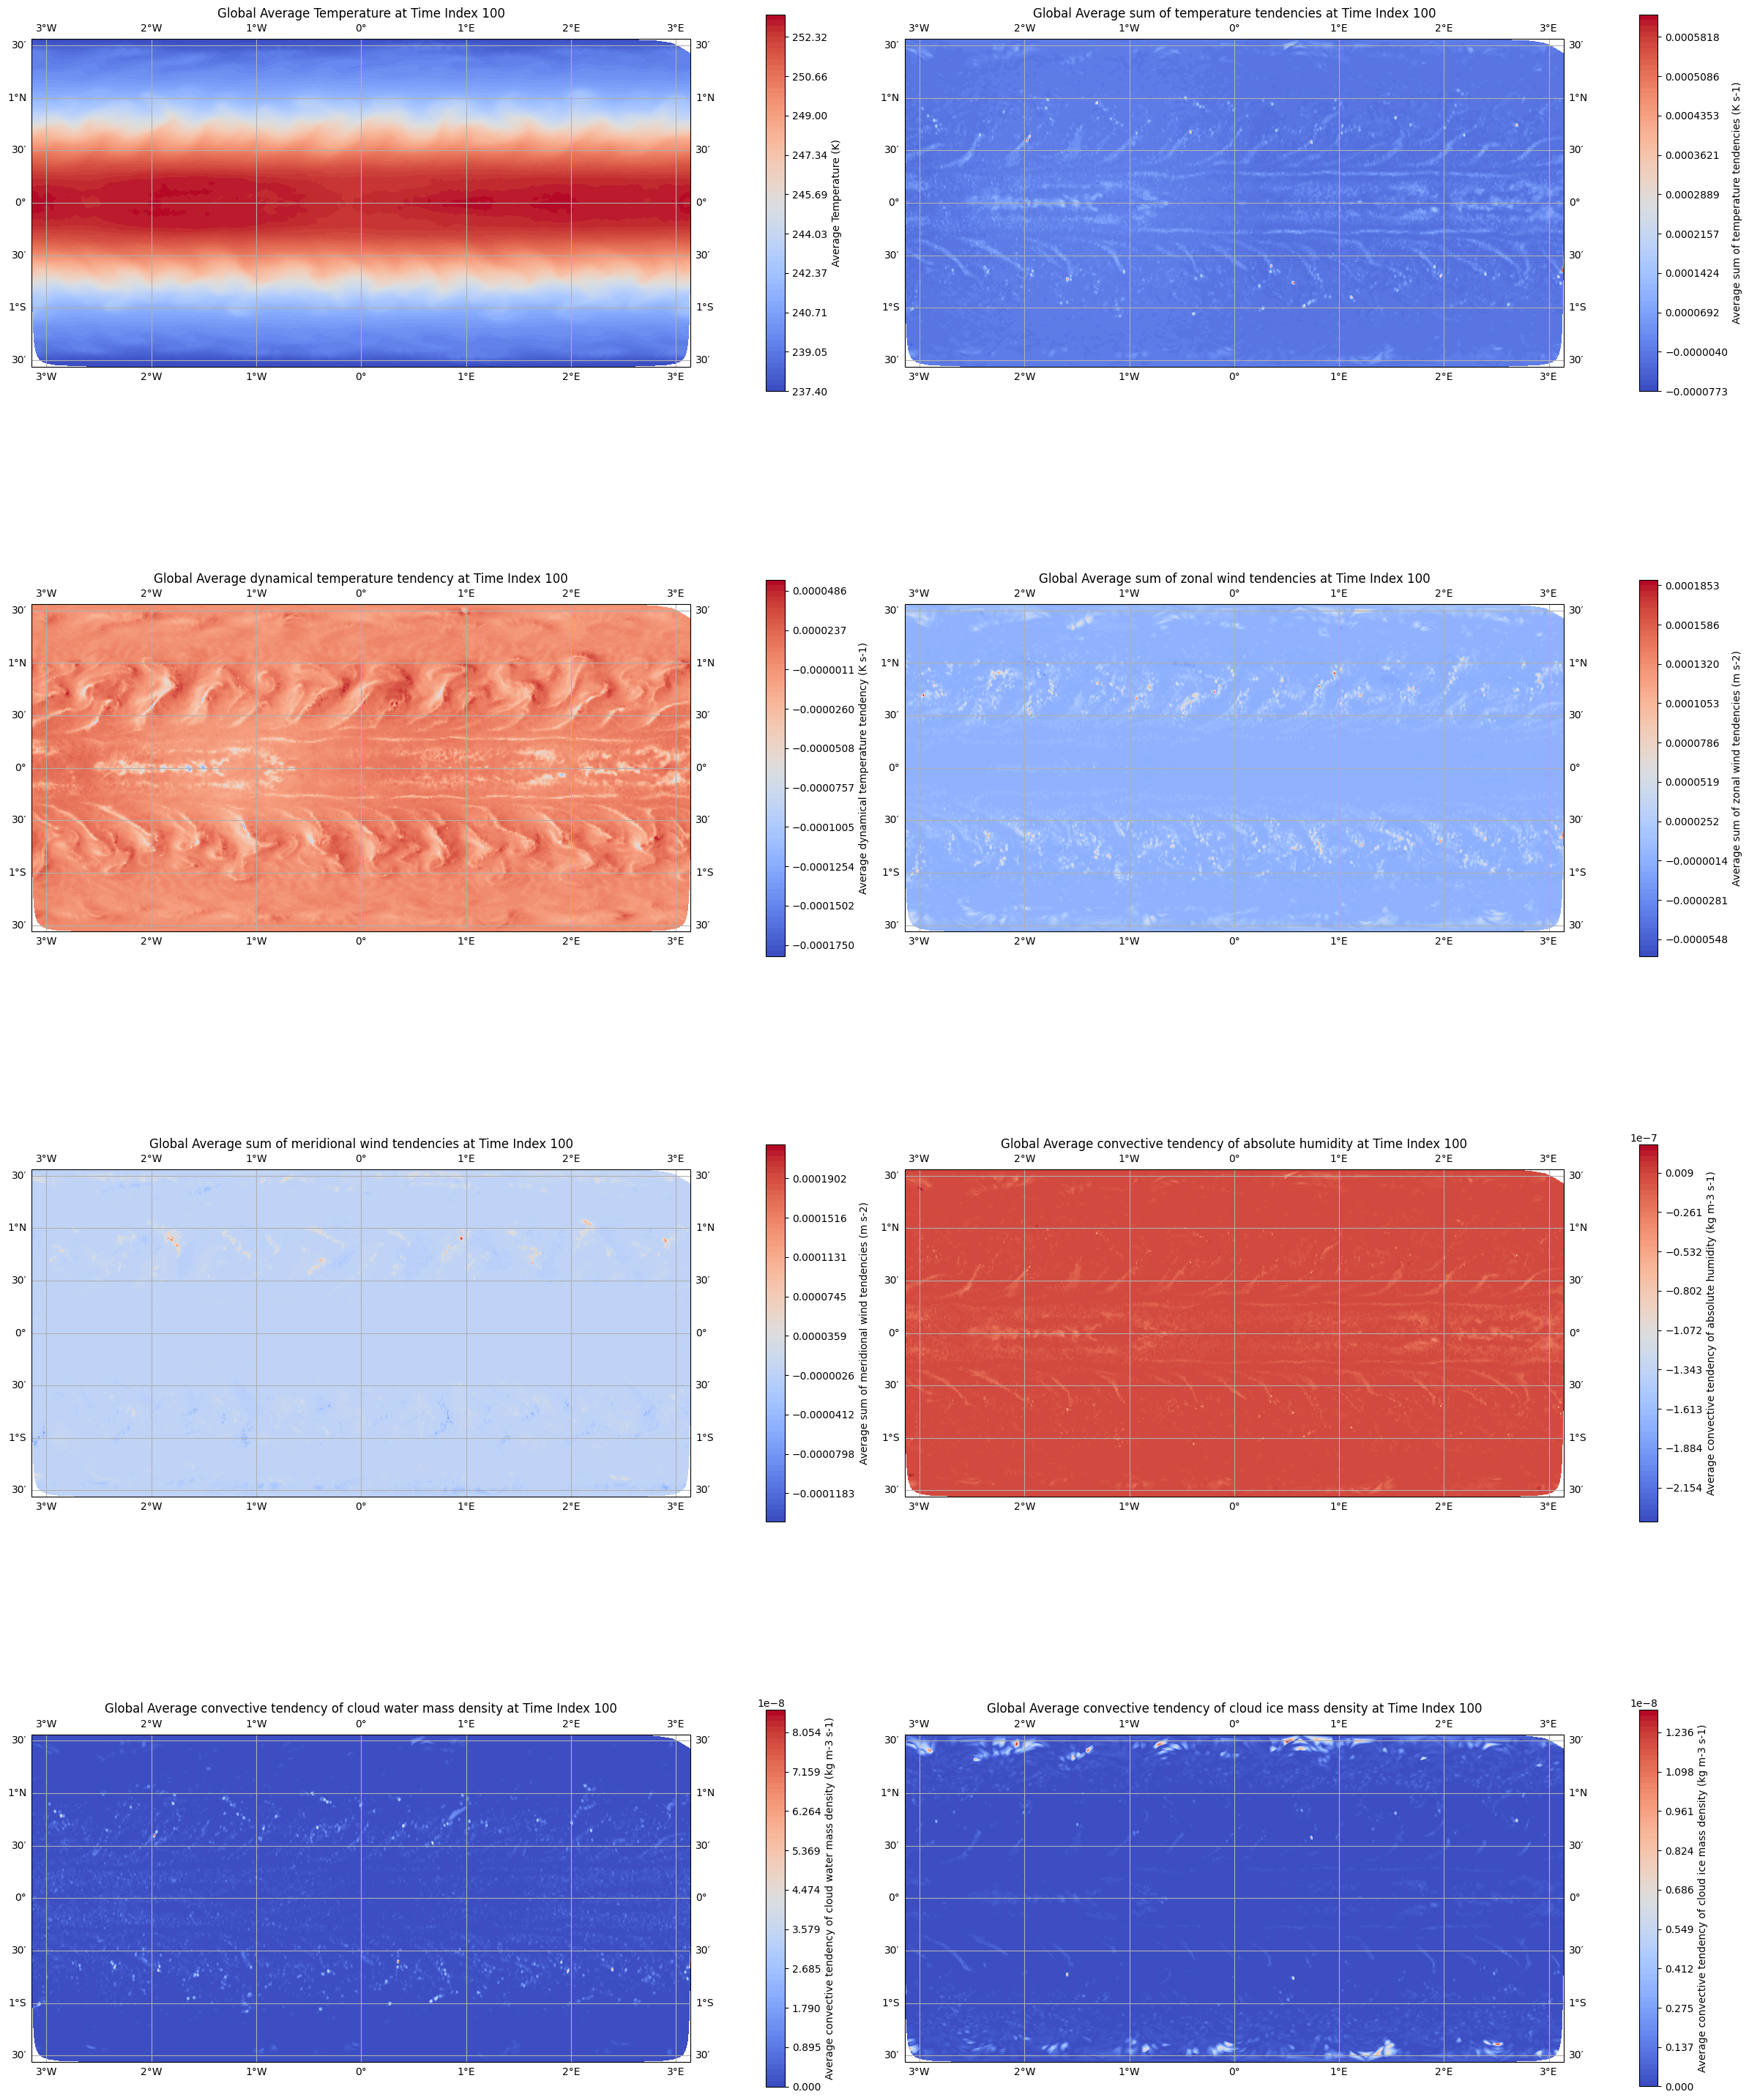

: 

In [14]:
time_index = 100  # Adjust this index to select a different time point
num_levels = 68 # Adjust the number of contour levels

variables = ['temp', 'ddt_temp_sum', 'ddt_temp_dyn', 'ddt_u_sum', 'ddt_v_sum', 'ddt_qv_conv', 'ddt_qc_conv', 'ddt_qi_conv']
num_plots = len(variables)
num_cols = 2
num_rows = (num_plots + 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(24, 8 * num_rows), subplot_kw={'projection': ccrs.PlateCarree()})

for i in range(num_plots):
    var = variables[i]
    row = i // num_cols
    col = i % num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]

    avg_data = ds[var].isel(time=time_index).mean(dim='height')
    avg_data_np = np.asarray(avg_data)

    levels = np.linspace(avg_data_np.min(), avg_data_np.max(), num=num_levels)
    contourf = ax.tricontourf(ds['clon'], ds['clat'], avg_data_np, levels=levels, transform=ccrs.PlateCarree(), cmap='coolwarm')
    cbar = fig.colorbar(contourf, ax=ax, orientation='vertical', fraction=0.025, pad=0.1)
    cbar.set_label(f"Average {ds[var].attrs.get('long_name', var)} ({ds[var].attrs.get('units', '')})")
    ax.set_title(f"Global Average {ds[var].attrs.get('long_name', var)} at Time Index {time_index}")

    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Remove any unused subplots
for i in range(num_plots, num_rows * num_cols):
    row = i // num_cols
    col = i % num_cols
    fig.delaxes(axes[row, col] if num_rows > 1 else axes[col])
e
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
height_index = 10
time_index = 150

print(f"ddt_qc_conv at height index 30: {ds['ddt_qc_conv'].isel(time=time_index, height=height_index).values}")
print(f"ddt_qi_conv at height index 30: {ds['ddt_qi_conv'].isel(time=time_index, height=height_index).values}")

height_index=68
print(f"ddt_qc_conv at height index 68: {ds['ddt_qc_conv'].isel(time=time_index, height=height_index).values}")
print(f"ddt_qi_conv at height index 68: {ds['ddt_qi_conv'].isel(time=time_index, height=height_index).values}")


ddt_qc_conv at height index 30: [0. 0. 0. ... 0. 0. 0.]
ddt_qi_conv at height index 30: [0. 0. 0. ... 0. 0. 0.]
ddt_qc_conv at height index 68: [0. 0. 0. ... 0. 0. 0.]
ddt_qi_conv at height index 68: [0. 0. 0. ... 0. 0. 0.]


In [ ]:
ds.shape
